In [48]:
# from scipy.integrate import trapezoid as trapz
from datetime import datetime
import os
import shutil
import pandas as pd
#!/anaconda3/bin/python
from math import cos, sin, pi, sqrt
from numpy import (
    array, linspace, arange, loadtxt, vectorize, pi as npi, exp, zeros,
    empty, log, log2, finfo, true_divide, asarray, where, partition, isnan, nan,
    ones, argmax, argmin, set_printoptions, diagonal, round, inf,concatenate, sin, cos
    )
import imageio
from numpy.random import random
from scipy.integrate import trapezoid as trapz
from scipy.signal import correlate2d
from matplotlib import rcParams, rc, ticker, colors, cm
from matplotlib.style import use
from matplotlib.pyplot import subplots, close
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from os import getcwd
from datetime import datetime
import os
from matplotlib.patches import Rectangle
import matplotlib.font_manager as font_manager
import pyximport
import numpy as np
from matplotlib.ticker import ScalarFormatter
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit, fsolve
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

pyximport.install()

from utilities import (
    calc_flux #, calc_learning_rate
    )
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica']})
rc('text', usetex=True)


In [49]:
f1 = -2.0

In [50]:
def set_params(model, n0,n1,f0,f1=-2.0,E0=2.0,E1=2.0):
    N = 100
    
     # energy scale of Fo
    Ecouple = 20.0 # energy scale of coupling between Fo and F1


    psi_0 = f0
    psi_1 = f1
    psi_0_n = f0
    psi_1_n = f1
    
    if model =="model4" or model =="model2" or model=="BFM":
        psi_0_n = n0*psi_0/8
        psi_1_n = n1*psi_1/3
        

    

    m0 = 1.0
    m1 = 1.0
    beta = 1.0
    gamma = 1000.0
    phase = 0.0

    

    return (
        E0, Ecouple, E1,  psi_0, psi_1, psi_0_n, psi_1_n, 
        n0, n1,
        m0, m1, phase,beta, gamma, model
        ) 
def infinite_eff(psi_0,psi_1,n0,n1,model):
    '''gets the psi_0/1 that is applied to model 1,3 
    (dont divide it for mod 2,4 before hand)'''
    
    if model=="model1":
        if abs(psi_0)>abs(psi_1):
            eff = - psi_1/psi_0
        else:
            eff = - psi_0/psi_1
    if model == "model2":
        if abs(n0*psi_0/8)>abs(n1*psi_1/3):
            eff = - (n1*psi_1/3)/(n0*psi_0/8)
        elif abs(n0*psi_0/8)==abs(n1*psi_1/3):
            eff =-1
        else:
            eff = - ((n0*psi_0/8)/(n1*psi_1/3))
    if model=="model3":
        X2 = (psi_0*((n1*psi_0/n0) + psi_1))
        X1 =(psi_1*(psi_0 + (n0*psi_1/n1)))
        if X2 != 0:
            if abs(psi_0/n0)>abs(psi_1/n1):
                eff = - X1/X2
            else:
                eff = - (X1/X2)**(-1)
        else:
            eff = 0
    if model == "model4":
        psi_0 = psi_0*n0/8
        psi_1 = psi_1*n1/3
        
        X2 = (psi_0*((n1*psi_0/n0) + psi_1))
        X1 =(psi_1*(psi_0 + (n0*psi_1/n1)))
        if X2 != 0:
            if abs(psi_0/n0)>abs(psi_1/n1):
                eff = - X1/X2
            else:
                eff = - (X1/X2)**(-1)
        else:
            eff = 0
            
        # eff = ["undefined" if x == -1 else x for x in eff]
    return eff

In [51]:
import setuptools  # Ensures distutils is available
import pyximport
pyximport.install()
from scipy.integrate import trapezoid as trapz
import matplotlib.cm as cm
from datetime import datetime
import os
import shutil
import pandas as pd
#!/anaconda3/bin/python
from math import cos, sin, pi, sqrt
from numpy import (
    array, linspace, arange, loadtxt, vectorize, pi as npi, exp, zeros,
    empty, log, log2, finfo, true_divide, asarray, where, partition, isnan, nan,
    ones, argmax, argmin, set_printoptions, diagonal, round, inf,concatenate, sin, cos
    )
import imageio
from numpy.random import random
from scipy.integrate import trapezoid as trapz
from scipy.signal import correlate2d
from matplotlib import rcParams, rc, ticker, colors, cm
from matplotlib.style import use
from matplotlib.pyplot import subplots, close
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from os import getcwd
from datetime import datetime
import os
from matplotlib.patches import Rectangle
import matplotlib.font_manager as font_manager
import pyximport
import numpy as np
from matplotlib.ticker import ScalarFormatter
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit, fsolve
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib
# Install setuptools to resolve the distutils issue
%pip install setuptools

import pyximport
pyximport.install()

from utilities import (
    calc_flux #, calc_learning_rate
    )
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica']})
rc('text', usetex=True)


def infinite_eff(psi_0,psi_1,n0,n1,model):
    '''gets the psi_0/1 that is applied to model 1,3 
    (dont divide it for mod 2,4 before hand)'''
    
    if model=="model1":
        if abs(psi_0)>abs(psi_1):
            eff = - psi_1/psi_0
        else:
            eff = - psi_0/psi_1
    if model == "model2":
        if abs(n0*psi_0/8)>abs(n1*psi_1/3):
            eff = - (n1*psi_1/3)/(n0*psi_0/8)
        elif abs(n0*psi_0/8)==abs(n1*psi_1/3):
            eff =-1
        else:
            eff = - ((n0*psi_0/8)/(n1*psi_1/3))
    if model=="model3":
        X2 = (psi_0*((n1*psi_0/n0) + psi_1))
        X1 =(psi_1*(psi_0 + (n0*psi_1/n1)))
        if X2 != 0:
            if abs(psi_0/n0)>abs(psi_1/n1):
                eff = - X1/X2
            else:
                eff = - (X1/X2)**(-1)
        else:
            eff = 0
    if model == "model4":
        psi_0 = psi_0*n0/8
        psi_1 = psi_1*n1/3
        
        X2 = (psi_0*((n1*psi_0/n0) + psi_1))
        X1 =(psi_1*(psi_0 + (n0*psi_1/n1)))
        if X2 != 0:
            if abs(psi_0/n0)>abs(psi_1/n1):
                eff = - X1/X2
            else:
                eff = - (X1/X2)**(-1)
        else:
            eff = 0
            
        # eff = ["undefined" if x == -1 else x for x in eff]
    return eff




[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [52]:
from matplotlib.ticker import ScalarFormatter

# Set logarithmic scale
ax.set_xscale('log')

# Use ScalarFormatter
formatter = ScalarFormatter()
formatter.set_scientific(False)  # Disable scientific notation
ax.xaxis.set_major_formatter(formatter)

In [53]:
def plot_P_mu0_var_E0(target_dir,model,n0_array,n1_array,E0_array,f0_array,Ec_array,f1=-2.0):
    '''wrong timescale used in paper'''
    timescale = 1.5 * 10**4 
    '''timescale used in thesis'''
    timescale = 4.8 * 10**7 
    #individually plotting for each model P vs no for various Ec values in one single plot
    colors = ["blue","green","red","purple","brown","pink","cyan","magenta"]
    
    fig_two,ax_two = plt.subplots(1, int(len(Ec_array)), figsize=(4*int(len(Ec_array)),3), sharey="row")
    ax_two[0].set_ylabel(r"$\mathrm{output \ power} \ \beta\mathcal{P}_{1}\ (\rm{s}^{-1})$", fontsize=18)
    ax_two[0].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    for i in range(len(Ec_array)):
        ax_two[i].set_title(fr"$\beta E_{{\rm c}} = {int(Ec_array[i])}$", fontsize=19)
        ax_two[i].set_xlabel(r"$\mu_{\rm o}$", fontsize=18)
        # ax_two[i].set_xscale("log")
        # ax_two[i].set_yscale("symlog")
        # ax_two[i].set_xlim(left=0.99, right=10.5)
        ax_two[i].tick_params(labelsize=15, axis='both')
        ax_two[i].spines['right'].set_visible(False)
        ax_two[i].spines['top'].set_visible(False)
        ax_two[i].set_xticks([1,2,5,10])
        ax_two[i].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
        ax_two[i].yaxis.offsetText.set_fontsize(15) 
    
    for jj, Ec in enumerate(Ec_array):
        #fig for P vs n0
        fig, ax = plt.subplots(1, 1, figsize=(5,5))
        #fig6 for P0 vs n0
        fig6, ax6 = plt.subplots(1, 1, figsize=(5,5))
        #fig1 for eta vs n0
        fig1, ax1 = plt.subplots(1, 1, figsize=(5,5))
        #fig2 for j1 vs n0
        fig2, ax2 = plt.subplots(1, 1, figsize=(5,5))
        #fig2 for jo vs n0
        fig5, ax5 = plt.subplots(1, 1, figsize=(5,5))
        #fig3 for jslip vs n0
        fig3, ax3 = plt.subplots(1, 1, figsize=(5,5))
        # #fig4 for eta if assume fo always wins
        fig4, ax4 = plt.subplots(1, 1, figsize=(5,5))
        #fig7 P1 vs. eta
        fig7, ax7 = plt.subplots(1, 2, figsize=(8,4), sharey="row")
        #fig8 for jinch vs n0
        fig8, ax8 = plt.subplots(1, 1, figsize=(5,5))
        
        # ax.axhline(0.0,color="black", lw=1.0)
        # ax3.axhline(0.0,color="black", lw=1.0)
        # ax6.axhline(0.0,color="black", lw=1.0)
        # ax4.axhline(0.0,color="black", lw=1.0)
        # ax2.axhline(0.0,color="black", lw=1.0)
        # ax5.axhline(0.0,color="black", lw=1.0)
        # ax1.axhline(1.0,color="black", lw=1.0)
        
        index = int(model[-1])-1
        Ecouple= []
        maximizing_mu0 = []
        '''analytical mathematica results'''
        # if model == "model2":
        #     p = False
        #     if Ec == 9.0:
        #         df = pd.read_csv("/Users/sarealles/Desktop/research/May25/mathematica_J1_vs_n1_Ec_9.csv")
        #         p = True
        #     if Ec==15.0:
        #         df = pd.read_csv("/Users/sarealles/Desktop/research/May25/mathematica_J1_vs_n1_Ec_15.csv")
        #         p = True
        #     if Ec==4.0:
        #         df = pd.read_csv("/Users/sarealles/Desktop/research/May25/mathematica_J1_vs_n1_Ec_4.csv")
        #         p = True
        #     if p:
        #         ax.scatter(array(df["n"][0:30]),timescale*2*2*pi*array(df["J"][0:30]),marker='s',color = "black", label=r"$\mathrm{analytical}$",s = 50)
        #         y =-8*(10**4)*np.ones(40)
        #         ax.fill_between(np.arange(0,40),y , where=(y < 0), color='red', alpha=0.05)
        #         ax.fill_between(np.arange(0,40),y , where=(y < 0), color='red', alpha=0.05)
        for n1 in n1_array:
            for i,E0 in enumerate(E0_array):
                E1 = E0
                f0 = f0_array[i]
                n0_exists = []
                n0_exists_0 = []
                P_at_Ec = []
                P0_at_Ec = []
                eta_at_Ec = []
                eta_at_inf = []
                eta_Fo_wins = []
                j1_at_Ec = []
                j1_at_0 = []
                jo_at_Ec = []
                jo_at_0 = []
                jslip_at_Ec = []
                
                for n0 in n0_array:
                    params = set_params(model, n0,n1,f0,f1,E0,E1)
                    n0n1_str = str(int(n0))+"_"+ str(int(n1))
                    target_dir_temp = target_dir +f"E0_{int(E0)}/pfe/" +n0n1_str
                
                    [
                    E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                    m0, m1, phase,beta, gamma,__
                    ] = params
                    
                
                    # input_file_name = ("/" + model +"_dt_{7}_N_{8}"+ "_flux_power_efficiency_"
                    # + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    #change the input name
                    input_file_name = ("/" + model + "_flux_power_efficiency_"
                    + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    
                    if target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase) not in os.listdir(target_dir_temp):
                        print("file not found: ", target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase))
                    Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                    target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase),unpack=True, usecols=(0,1,2,3,4,5,6))
                    
                    # Convert Ec_list to a list if it is a single value
                    if isinstance(Ec_list, float):
                        Ec_list = [Ec_list]
                        integrate_power_Y = [integrate_power_Y]
                        integrate_power_X = [integrate_power_X]
                        integrate_flux_X = [integrate_flux_X]
                        integrate_flux_Y = [integrate_flux_Y]
                        efficiency_mod = [efficiency_mod]
                        efficiency = [efficiency]

                    # print(integrate_power_Y)
                    for j in range(len(Ec_list)):
                        if Ec_list[j] == Ec:
                            n0_exists.append(int(n0))
                            P0_at_Ec.append(2*pi*integrate_power_X[j])
                            P_at_Ec.append(-2*pi*integrate_power_Y[j])
                            eta_at_Ec.append(efficiency_mod[j])
                            j1_at_Ec.append(integrate_flux_Y[j])
                            jo_at_Ec.append(integrate_flux_X[j])
                            eta_Fo_wins.append(efficiency[j])
                            if model =="model3" or model=="model4":
                                jslip_at_Ec.append(n0*integrate_flux_X[j]-n1*integrate_flux_Y[j])
                            else:
                                jslip_at_Ec.append(integrate_flux_X[j]-integrate_flux_Y[j])
                        if Ec_list[j] == 0.0 or Ec_list[j] == 0:
                            j1_at_0.append(integrate_flux_Y[j])
                            jo_at_0.append(integrate_flux_X[j])
                            n0_exists_0.append(int(n0))
                                
                            
                    eta_at_inf.append(infinite_eff(psi_0,psi_1,n0,n1,model))
                # print("J0: ",jo_at_Ec)
                # print("J1: ",j1_at_Ec)
                # print("eff is ",eta_at_Ec)
                # print("n0: ",n0_exists)
                if len(n0_exists)!=0:
                    Ecouple.append(Ec)
                    maximizing_mu0.append((f0/8)*array(n0_exists[argmax(j1_at_Ec)]))
                # print(fr"at {Ec}, n0 that maximizes J1 is: {n0_exists[argmax(j1_at_Ec)]}")
                    
                if model =="model2" or model=="model4":
                    x = str(psi_0/8)
                    psi_0 = "\\frac{n_o}{4}"
                    # psi_0 = str(psi_0)
                    f_o = "\\left| \\frac{\\mu_o}{\\mu_1} \\right|"
                else:
                    # f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                    f_o = "\\Delta \\mu_o"
                
                '''normal plots'''
                # fig.suptitle(fr"${model},\ n_1 = {n1}, \ Ec = {Ec}$", fontsize=12)
                # ax.plot((f0/8)*array(n0_exists),P_at_Ec, label = fr"${E0}$",marker ="o", lw=1.0,markersize=8)
                ax.tick_params(labelsize=15, axis='both')
                ax.set_xlabel(r"$\mu_o$", fontsize=15)
                ax.set_xticks(n0_exists)
                ax.set_ylabel(r"$\mathrm{output \ power} \ \beta\mathcal{P}_{1}\ (\rm{s}^{-1})$", fontsize=15)
                '''paper plot, only barrierless E_o =0'''
                # fig.suptitle(r"$\mathrm{scaling \ force}$", fontsize=24)
                # ax.scatter(array(n0_exists),timescale*array(P_at_Ec), label = r"$\mathrm{simulation}$",marker ="*", s=30,color = "orange")
                # ax.set_xlabel(r"$\# \ \mathrm{subunits \ on} \ F_{\rm o} \ (n_{\rm o})$", fontsize=15)

                ax.scatter((f0/8)*array(n0_exists),timescale*array(P_at_Ec), label = r"$\mathrm{simulation}$",marker ="*", s=30)

                ax_two[jj].plot((f0/8)*array(n0_exists), timescale*array(P_at_Ec), label = fr"${int(E0)}$",marker ="d", color = colors[i])
                ax.set_xlabel(r"$\mu_{\rm o}$", fontsize=15)

                #ax.legend(loc='upper right', prop={'size':12})
                # ax.plot([6,9,12,15,18,21,24,27,30],[1.0, 0.989, 0.961, 0.916, 0.854, 0.791, 0.81, 0.83, 0.836])
                #############################♯
                # deg=4
                # fit_coeffs = np.polyfit(n0_exists, P_at_Ec, deg)
                # fit_curve = np.polyval(fit_coeffs, n0_exists)
                # equation = " + ".join([f"${coef:.6f}*x^{deg}$" for coef, deg in zip(fit_coeffs, range(len(fit_coeffs)-1, -1, -1))])
                # print(f"Fitted Polynomial Equation Ec = {Ec}: y = {equation}")
                # ax.plot(n0_exists, fit_curve)
                # print(f"Fitted Polynomial Equation: y = {equation}")
                ############################# 
                fig1.suptitle(fr"${model} ,\ n_1 = {n1}, \ Ec = {Ec}$", fontsize=12)
                ax1.plot((f0/8)*array(n0_exists),eta_at_Ec, label = fr"${E0}$",marker ="o", lw=1.0,markersize=8)
                # for i,e in enumerate(eta_at_Ec):
                #     if e > 0.5:
                #         print(fr"eta is {e} at Ec = {Ec}, n0 = {n0_exists[i]}")
        
                ax1.tick_params(labelsize=15, axis='both')
                ax1.set_xlabel(r"$\mu_o$", fontsize=15)
                ax1.set_ylabel(r"$\eta$", fontsize=15)
                #ax1.legend(loc='upper right', prop={'size':12})
                
                fig7.suptitle(fr"${model} ,\ n_1 = {n1}, \ Ec = {Ec}$", fontsize=12)
                ax7[0].plot(P_at_Ec,eta_at_Ec, label = fr"${E0}$",marker ="o", lw=1.0,markersize=8)
                ax7[1].plot(P0_at_Ec,eta_at_Ec, label = fr"${E0}$",marker ="o", lw=1.0,markersize=8)
                # ax7[1].set_title(r"$\mathcal{P}_{o}$")
                # ax7[0].set_title(r"$\mathcal{P}_{1}$")
                ax7[0].tick_params(labelsize=15, axis='both')
                ax7[1].tick_params(labelsize=15, axis='both')
                ax7[0].set_xlabel(r"$\mathcal{P}_{1}$", fontsize=15)
                ax7[1].set_xlabel(r"$\mathcal{P}_{o}$", fontsize=15)
                ax7[0].set_ylabel(r"$\eta$", fontsize=15)
                
                fig2.suptitle(fr"${model},\ n_1 = {n1}, \ Ec = {Ec}$", fontsize=12)
                ax2.plot((f0/8)*array(n0_exists),j1_at_Ec, label = fr"${E0}$",marker ="o",lw=1.0, markersize=8)
                ax2.tick_params(labelsize=15, axis='both')
                ax2.set_xlabel(r"$\mu_o$", fontsize=15)
                ax2.set_xticks(n0_exists)
                ax2.set_ylabel(r"$J_{1}$", fontsize=15)
                
                fig5.suptitle(fr"${model},\ n_1 = {n1}, \ Ec = {Ec}$", fontsize=12)
                ax5.plot((f0/8)*array(n0_exists),jo_at_Ec, label = fr"${E0}$",marker ="o",lw=1.0, markersize=8)

                ax5.tick_params(labelsize=15, axis='both')
                ax5.set_xlabel(r"$\mu_o$", fontsize=15)
                ax5.set_xticks(n0_exists)
                ax5.set_ylabel(r"$J_{o}$", fontsize=15)
                
                fig3.suptitle(fr"${model},\ n_1 = {n1}, \ Ec = {Ec}$", fontsize=12)
                ax3.plot((f0/8)*array(n0_exists),jslip_at_Ec, label = fr"${E0}$",marker ="o",color = colors[i],lw=1.0, markersize=8)
                ax3.plot((f0/8)*array(n0_exists_0),jo_at_0, label = fr"${E0}$",marker ="s",color = colors[i],lw=1.0, markersize=2)

                fig8.suptitle(fr"${model},\ n_1 = {n1}, \ Ec = {Ec}$", fontsize=12)
                # ax8.plot((f0/8)*array(n0_exists),array(jo_at_Ec)-array(jslip_at_Ec), label = fr"${E0}$",marker ="d",color = colors[i],lw=1.0, markersize=8)
                ax8.plot((f0/8)*array(n0_exists),array(j1_at_Ec), label = fr"${E0}$",marker ="d",color = colors[i],lw=1.0, markersize=8)
                # ax8.plot((f0/8)*array(n0_exists_0),array(j1_at_0), label = fr"${E0}$",marker ="s",color = colors[i],lw=1.0, markersize=2)


                ax3.tick_params(labelsize=15, axis='both')
                ax3.set_xlabel(r"$\mu_o$", fontsize=15)
                ax3.set_xticks(n0_exists)
                ax3.set_ylabel(r"$J_{slip}$", fontsize=15)
                
                ax8.tick_params(labelsize=15, axis='both')
                ax8.set_xlabel(r"$\mu_o$", fontsize=15)
                ax8.set_xticks(n0_exists)
                ax8.set_ylabel(r"$J_{inch}$", fontsize=15)

                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                # ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                fig4.suptitle(fr"${model},\ \eta ,\ n_1 = {n1}, \ Ec = {Ec}$", fontsize=12)
                ax4.plot((f0/8)*array(n0_exists),eta_Fo_wins, label = fr"${E0}$",marker ="o",lw=1.0, markersize=8)
                ax4.tick_params(labelsize=15, axis='both')
                ax4.set_xlabel(r"$\mu_o$", fontsize=15)
                ax4.set_xticks(n0_exists)
                ax4.set_ylabel(r"$\eta_{Fo_wins}$", fontsize=15)


                fig6.suptitle(fr"${model},\ n_1 = {n1}, \ Ec = {Ec}$", fontsize=15)
                ax6.plot((f0/8)*array(n0_exists),P0_at_Ec, label = fr"${E0}$",marker ="o", lw=1.0,markersize=8)
                ax6.tick_params(labelsize=15, axis='both')
                ax6.set_xlabel(r"$\mu_o$", fontsize=15)
                ax6.set_xticks(n0_exists)
                ax6.set_ylabel(r"$\mathcal{P}_{o}$", fontsize=15)
                
                
                ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax2.spines['right'].set_visible(False)
                ax2.spines['bottom'].set_visible(False)
                ax2.spines['top'].set_visible(False)
                
                ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax5.spines['right'].set_visible(False)
                ax5.spines['bottom'].set_visible(False)
                ax5.spines['top'].set_visible(False)
                
                ax7[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[0].spines['right'].set_visible(False)
                ax7[0].spines['bottom'].set_visible(False)
                ax7[0].spines['top'].set_visible(False)
                ax7[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[1].spines['right'].set_visible(False)
                ax7[1].spines['bottom'].set_visible(False)
                ax7[1].spines['top'].set_visible(False)
                
                ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax6.spines['right'].set_visible(False)
                ax6.spines['bottom'].set_visible(False)
                ax6.spines['top'].set_visible(False)
                
                ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax4.spines['right'].set_visible(False)
                ax4.spines['bottom'].set_visible(False)
                ax4.spines['top'].set_visible(False)
                
                # ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax3.spines['right'].set_visible(False)
                ax3.spines['bottom'].set_visible(False)
                ax3.spines['top'].set_visible(False)
                
                ax8.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax8.spines['right'].set_visible(False)
                ax8.spines['bottom'].set_visible(False)
                ax8.spines['top'].set_visible(False)
                
                ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax1.spines['right'].set_visible(False)
                ax1.spines['bottom'].set_visible(False)
                ax1.spines['top'].set_visible(False)
                
                ax.set_xscale("log")
                ax1.set_xscale("log")
                ax2.set_xscale("log")
                ax3.set_xscale("log")
                ax3.set_yscale("log")
                ax8.set_xscale("log")
                # ax8.set_yscale("log")
                ax4.set_xscale("log")
                ax5.set_xscale("log")
                ax6.set_xscale("log")
                ax7[0].set_xscale("symlog")
                ax7[1].set_xscale("symlog")
                # ax3.set_yscale("symlog")
            
                #ax.set_yscale("log")
            # ax1.plot(n0_array, eta_at_inf, label=fr"$E_{{\infty}}$", color="black", markersize=15)
        
        # ax1.plot([3,6,9,12,15,18,21], [0.36, 0.18, 0.12, 0.09, 0.07, 0.06, 0.05], label="8")
        # ax1.plot([3,6,9,12,15,18,21],[0.66, 0.59, 0.63, 0.65, 0.65, 0.65, 0.65], label = "12")
        # ax1.plot([3,6,9,12,15,18,21],[0.44, 0.2, 0.14, 0.11, 0.09, 0.07, 0.06],label = "12*limit")
        ax.legend(prop={'size': 12}, title='$E_0$', frameon=False, ncol=1, labelspacing=0.05,
            bbox_to_anchor=(0.31, 0.6), loc='best')
        '''paper legend, barrierless'''
        ax.legend(prop={'size': 14}, title='', frameon=False, ncol=1, labelspacing=0.05,loc='best')
        # ax.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax1.legend(prop={'size':12},title='$E_0$', frameon= False, labelspacing=1)
        ax2.legend(prop={'size':12},title='$E_0$', frameon= False, labelspacing=1)
        ax3.legend(prop={'size':12},title='$E_0$', frameon= False, labelspacing=1)
        ax8.legend(prop={'size':12},title='$E_0$', frameon= False, labelspacing=1)
        ax4.legend(prop={'size':12},title='$E_0$', frameon= False, labelspacing=1)
        ax6.legend(prop={'size':12},title='$E_0$', frameon= False, labelspacing=1)
        ax5.legend(prop={'size':12},title='$E_0$', frameon= False, labelspacing=1)
        ax7[0].legend(prop={'size':12},title='$E_0$', frameon= False, labelspacing=1)
        '''following numbers are from mathematica nb'''
        ax8.hlines((-0.000536148)/(2*pi),xmin=0,xmax=30, color = colors[4],label = "E0=4")
        ax8.hlines(-0.002/(2*pi),xmin=0,xmax=30,color=colors[0],label = "E0=0")
        ax8.hlines(-0.00183441/(2*pi),xmin=0,xmax=30,color = colors[1],label = "E0=1")
        ax8.hlines(-0.00141843/(2*pi),xmin=0,xmax=30,color = colors[2],label = "E0=2")
        ax8.hlines(-0.000934189/(2*pi),xmin=0,xmax=30,color = colors[3],label = "E0=3")
        

            ################################
        # fig.savefig(fr"/Users/sarealles/Desktop/research/nov24/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{f0}.pdf")
        # fig.savefig(fr"/Users/sarealles/Desktop/research/nov24/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{f0}.png",dpi=500)
        # fig1.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_eta_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig2.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_J1_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        '''I dont remember what this next plot was for'''
        # ax.plot(0.5*array(n0_array), (array(n0_array)*0.5 - 2)/2000, color="black")
        '''if (mu0 -mu1) >> Ec'''
        # ax.plot(0.5*array(n0_array), -4*ones(len(n0_array))/1000, color="blue")

        ax.set_xscale('log')

        # Use ScalarFormatter
        formatter = ScalarFormatter()
        formatter.set_scientific(False)  # Disable scientific notation
        ax.xaxis.set_major_formatter(formatter)
        
        tick_locations = [1,2,5,10,20,30]  # Every 5th value, adjust as needed
        ax.set_xticks(tick_locations)
        ax.set_xticklabels([fr"$\mathrm{{{int(tick)}}}$" for tick in tick_locations])
        ax8.yaxis.offsetText.set_fontsize(13) 
        

        
        ax.set_ylim(bottom=-8*(10**4))
        ax.set_xlim(right=31)
        
        # fig.savefig(fr"/Users/sarealles/Desktop/research/Paper/barrierless_scaling_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{f0}.pdf", bbox_inches='tight')

        
        print("E0 is :", E0_array)
        print("j1 maximizing n0 is:", (maximizing_mu0))
        # plt.show()
    ax_two[0].legend(prop={'size': 13}, title=r'$\beta E_{\rm o} = \beta E_1 $', title_fontsize=13, frameon=False, ncol=1, labelspacing=0.5, loc='best')
    plt.tight_layout()  # Adjust layout to prevent overlap
    # fig_two.savefig(fr"/Users/sarealles/Desktop/research/Paper/P1_vs_mu0_legend_Ec.pdf", bbox_inches='tight')

    plt.show()   



file not found:  /Users/sarealles/Desktop/model2/Barrier_analysis/E0_0/pfe/1_3/model2_flux_power_efficiency_E0_0.0_E1_0.0_psi0_4.0_psi1_-2.0_n0_1.0_n1_3.0_phase_0.0_outfile.dat
file not found:  /Users/sarealles/Desktop/model2/Barrier_analysis/E0_0/pfe/2_3/model2_flux_power_efficiency_E0_0.0_E1_0.0_psi0_4.0_psi1_-2.0_n0_2.0_n1_3.0_phase_0.0_outfile.dat
file not found:  /Users/sarealles/Desktop/model2/Barrier_analysis/E0_0/pfe/3_3/model2_flux_power_efficiency_E0_0.0_E1_0.0_psi0_4.0_psi1_-2.0_n0_3.0_n1_3.0_phase_0.0_outfile.dat
file not found:  /Users/sarealles/Desktop/model2/Barrier_analysis/E0_0/pfe/4_3/model2_flux_power_efficiency_E0_0.0_E1_0.0_psi0_4.0_psi1_-2.0_n0_4.0_n1_3.0_phase_0.0_outfile.dat
file not found:  /Users/sarealles/Desktop/model2/Barrier_analysis/E0_0/pfe/5_3/model2_flux_power_efficiency_E0_0.0_E1_0.0_psi0_4.0_psi1_-2.0_n0_5.0_n1_3.0_phase_0.0_outfile.dat
file not found:  /Users/sarealles/Desktop/model2/Barrier_analysis/E0_0/pfe/6_3/model2_flux_power_efficiency_E0_0.0_

/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_9030/1895105930.py:110: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Desktop/model2/Barrier_analysis/E0_0/pfe/21_3/model2_flux_power_efficiency_E0_0.0_E1_0.0_psi0_4.0_psi1_-2.0_n0_21.0_n1_3.0_phase_0.0_outfile.dat"
  Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_9030/1895105930.py:110: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Desktop/model2/Barrier_analysis/E0_0/pfe/22_3/model2_flux_power_efficiency_E0_0.0_E1_0.0_psi0_4.0_psi1_-2.0_n0_22.0_n1_3.0_phase_0.0_outfile.dat"
  Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_9030/1895105930.py:110: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Desktop/model2/Barrier_ana

file not found:  /Users/sarealles/Desktop/model2/Barrier_analysis/E0_1/pfe/1_3/model2_flux_power_efficiency_E0_1.0_E1_1.0_psi0_4.0_psi1_-2.0_n0_1.0_n1_3.0_phase_0.0_outfile.dat
file not found:  /Users/sarealles/Desktop/model2/Barrier_analysis/E0_1/pfe/2_3/model2_flux_power_efficiency_E0_1.0_E1_1.0_psi0_4.0_psi1_-2.0_n0_2.0_n1_3.0_phase_0.0_outfile.dat
file not found:  /Users/sarealles/Desktop/model2/Barrier_analysis/E0_1/pfe/3_3/model2_flux_power_efficiency_E0_1.0_E1_1.0_psi0_4.0_psi1_-2.0_n0_3.0_n1_3.0_phase_0.0_outfile.dat
file not found:  /Users/sarealles/Desktop/model2/Barrier_analysis/E0_1/pfe/4_3/model2_flux_power_efficiency_E0_1.0_E1_1.0_psi0_4.0_psi1_-2.0_n0_4.0_n1_3.0_phase_0.0_outfile.dat
file not found:  /Users/sarealles/Desktop/model2/Barrier_analysis/E0_1/pfe/5_3/model2_flux_power_efficiency_E0_1.0_E1_1.0_psi0_4.0_psi1_-2.0_n0_5.0_n1_3.0_phase_0.0_outfile.dat
file not found:  /Users/sarealles/Desktop/model2/Barrier_analysis/E0_1/pfe/6_3/model2_flux_power_efficiency_E0_1.0_

/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_9030/1895105930.py:110: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Desktop/model2/Barrier_analysis/E0_2/pfe/21_3/model2_flux_power_efficiency_E0_2.0_E1_2.0_psi0_4.0_psi1_-2.0_n0_21.0_n1_3.0_phase_0.0_outfile.dat"
  Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_9030/1895105930.py:110: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Desktop/model2/Barrier_analysis/E0_2/pfe/22_3/model2_flux_power_efficiency_E0_2.0_E1_2.0_psi0_4.0_psi1_-2.0_n0_22.0_n1_3.0_phase_0.0_outfile.dat"
  Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_9030/1895105930.py:110: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Desktop/model2/Barrier_ana

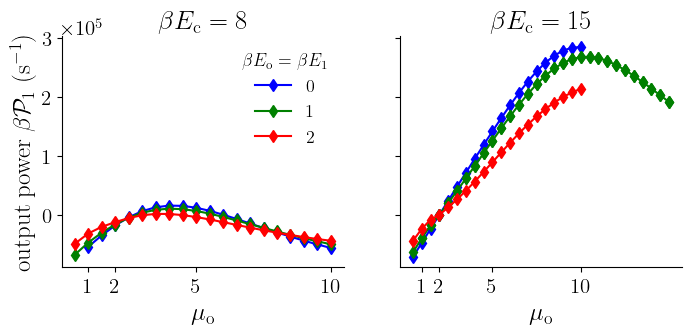

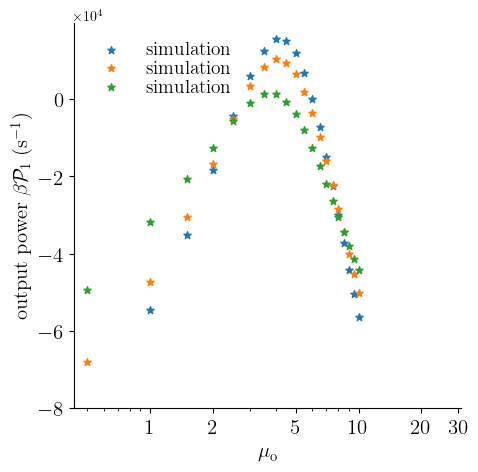

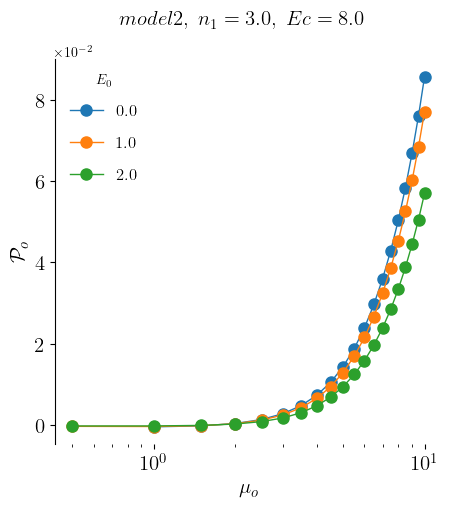

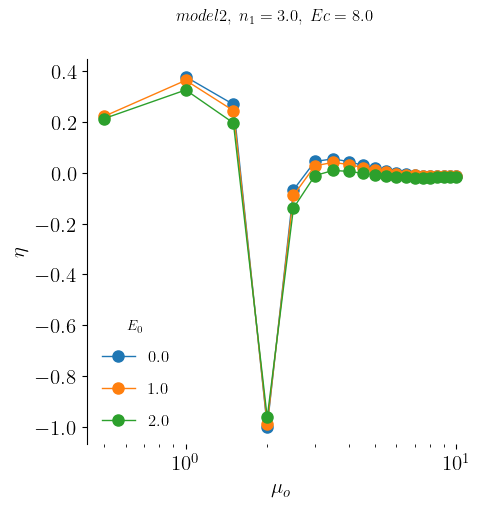

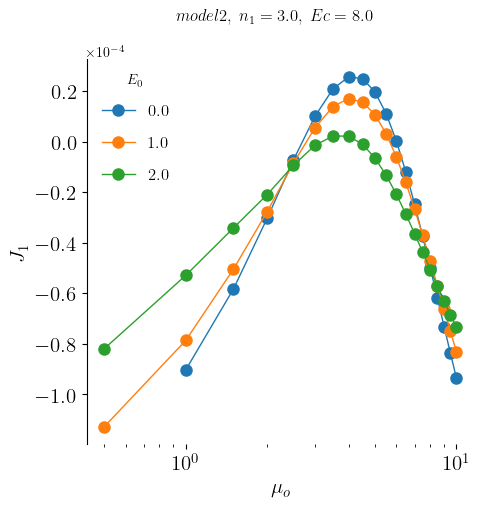

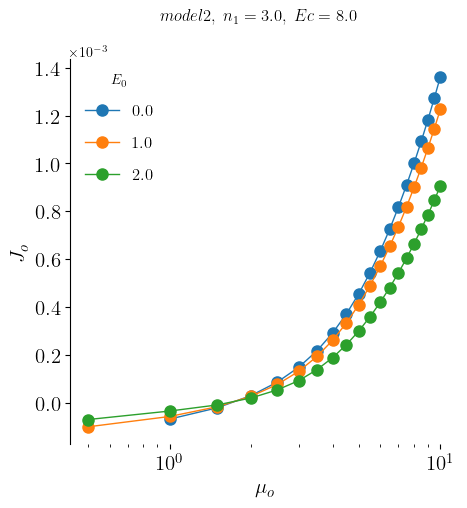

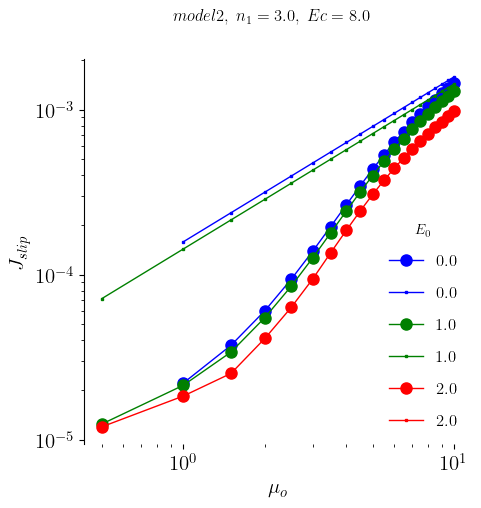

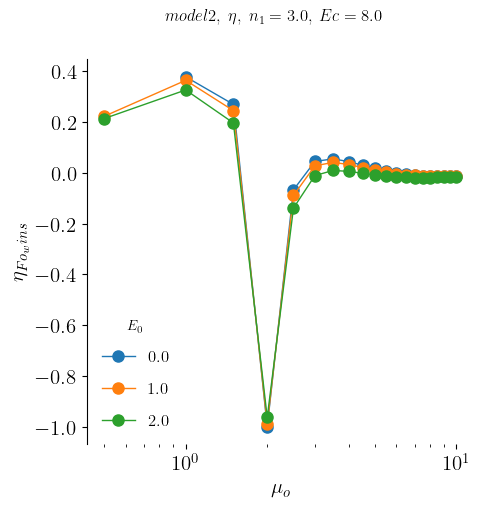

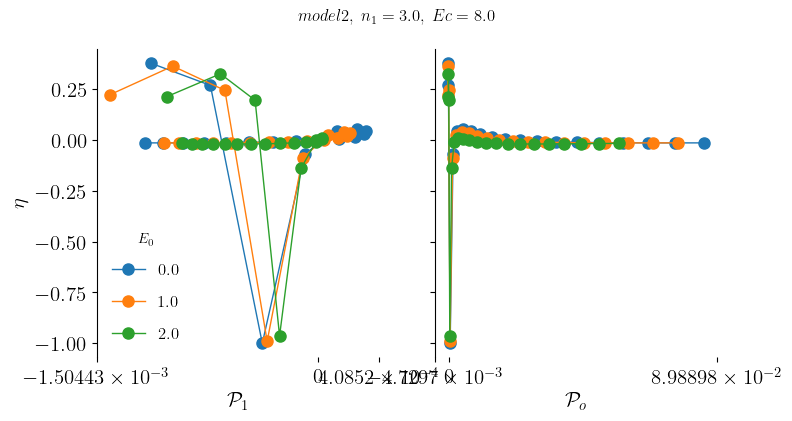

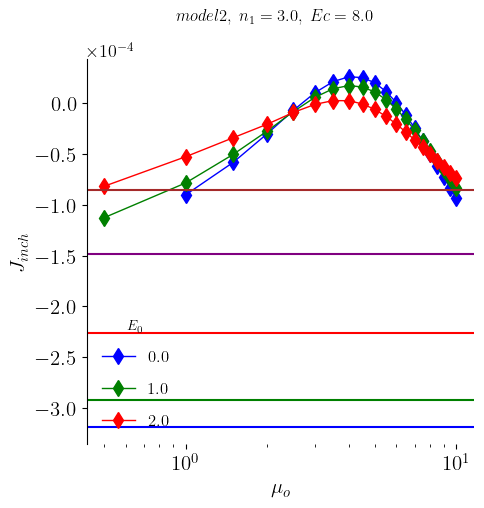

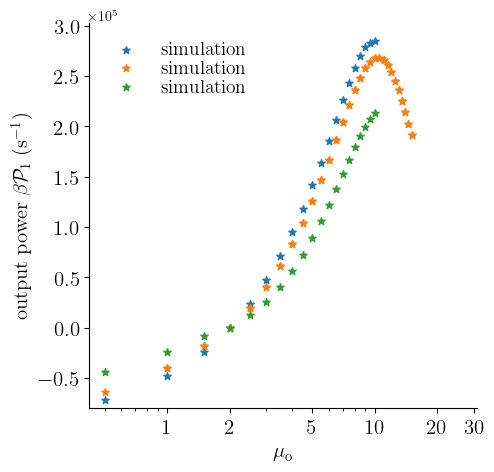

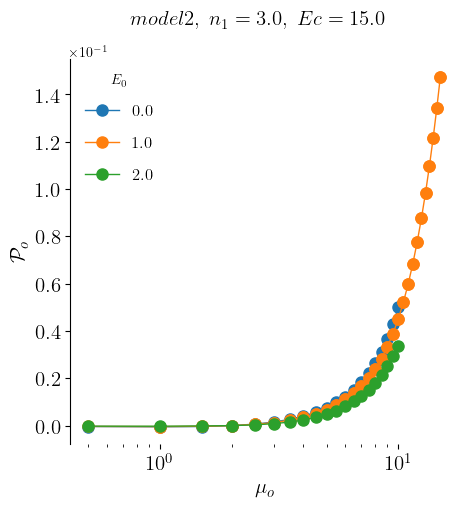

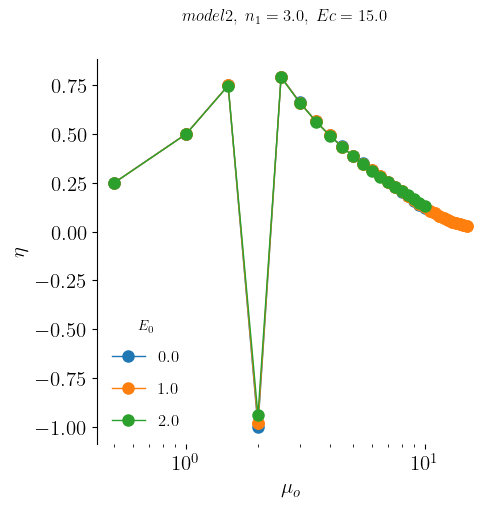

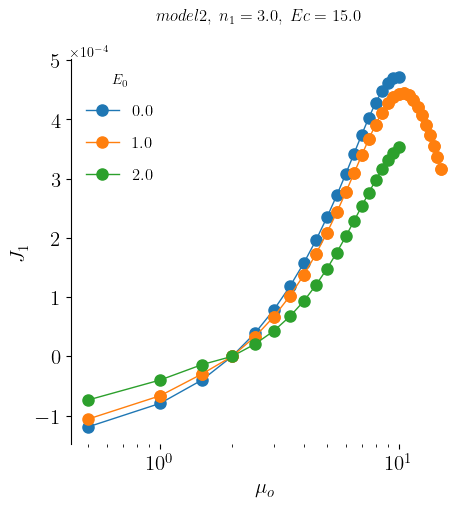

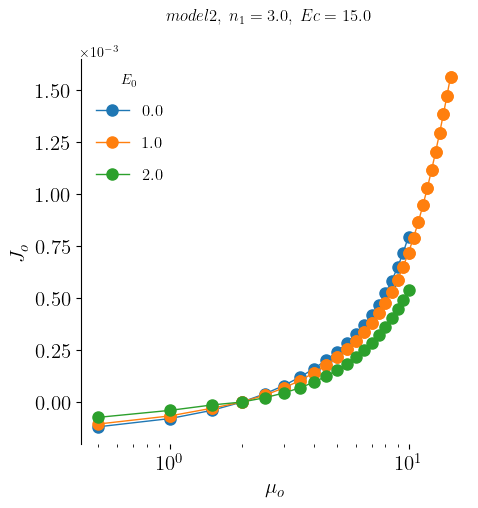

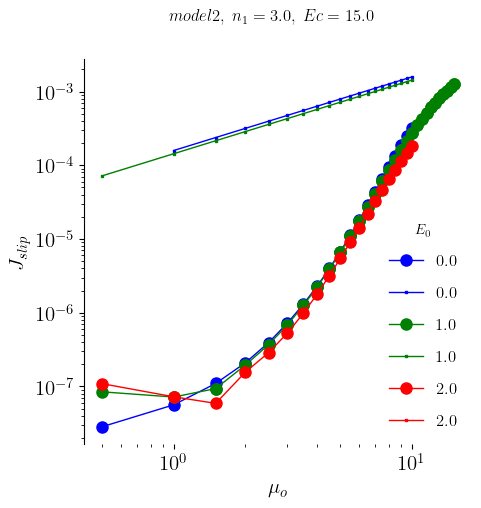

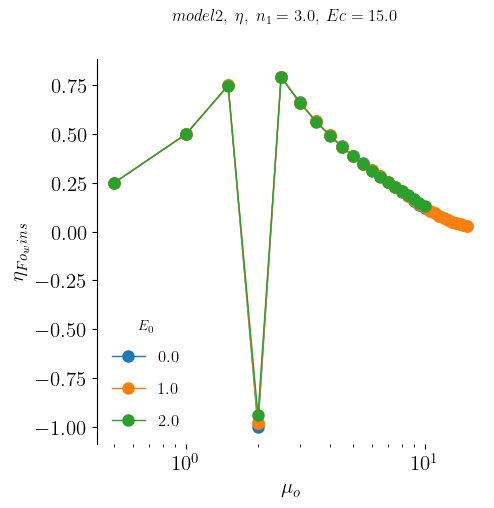

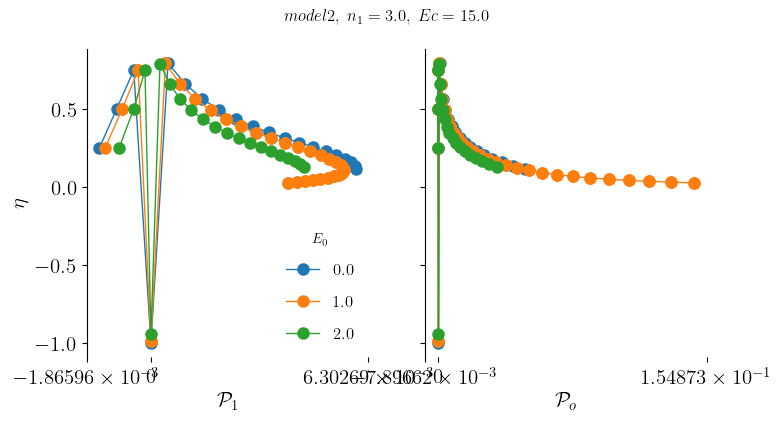

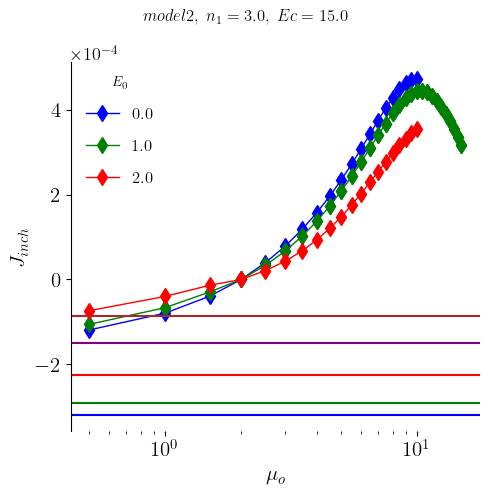

In [54]:
#A plot of P vs n0 for different Ec


target_dir = "/Users/sarealles/Desktop/model2/Barrier_analysis/"
#individual plots for each model


Ec_array = [0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,32.0,40.0,50.0,64.0,70.0,80.0,90.0,128.0] 
# Ec_array = [8.0,9.0,10.0,11.0,12.0]

# Ec_array = np.array([9.0,10.0,11.0, 12.0])

# Ec_array = [7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0]

# Ec_array = [5., 6., 7., 8., 9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19.]

Ec_array = [11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,32.0,40.0,50.0,64.0,70.0,80.0,90.0,128.0] 

# Ec_array = [7.5,8.0,8.5,9.0,9.5, 10.0, 10.5, 11.0, 11.5, 12.0,12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0]
n1_array = [3.0]
n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0] 
# n0_array = [3.0,6.0,12.0]
# n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0]
Ec_array = [1.0]
E0_array = [0.0,1.0,2.0,3.0,4.0]
f0_array = [4.0,4.0,8.0,8.0,8.0]

E0_array = [0.0,1.0,2.0]
f0_array = [4.0,4.0,4.0]

Ec_array = [8.0,15.0]
for model in ["model2"]:
    plot_P_mu0_var_E0(target_dir,model,n0_array,n1_array,E0_array,f0_array,Ec_array)
    plt.show()  


In [55]:
def plot_P_n0_individual(target_dir,model,n0_array,n1_array,Ec_array,f0,dt,N,E0,E1,vs_n0=True):
    timescale = 1.5 * 10**4 
    #individually plotting for each model P vs no for various Ec values in one single plot
    f1 = -2.0
    #fig for P vs n0
    fig, ax = plt.subplots(1, 1, figsize=(5,5))
    #fig6 for P0 vs n0
    fig6, ax6 = plt.subplots(1, 1, figsize=(5,5))
    #fig1 for eta vs n0
    fig1, ax1 = plt.subplots(1, 1, figsize=(5,5))
    #fig2 for j1 vs n0
    fig2, ax2 = plt.subplots(1, 1, figsize=(5,5))
    #fig2 for jo vs n0
    fig5, ax5 = plt.subplots(1, 1, figsize=(5,5))
    #fig3 for jslip vs n0
    fig3, ax3 = plt.subplots(1, 1, figsize=(5,5))
    # #fig4 for eta if assume fo always wins
    fig4, ax4 = plt.subplots(1, 1, figsize=(5,5))
    #fig7 P1 vs. eta
    fig7, ax7 = plt.subplots(1, 2, figsize=(8,4), sharey="row")
    
    # ax.axhline(0.0,color="black", lw=1.0)
    # ax3.axhline(0.0,color="black", lw=1.0)
    # ax6.axhline(0.0,color="black", lw=1.0)
    # ax4.axhline(0.0,color="black", lw=1.0)
    # ax2.axhline(0.0,color="black", lw=1.0)
    # ax5.axhline(0.0,color="black", lw=1.0)
    # ax1.axhline(1.0,color="black", lw=1.0)
    
    index = int(model[-1])-1
    Ecouple= []
    maximizing_n0 = []
    if vs_n0:
        for n1 in n1_array:
            for i,Ec in enumerate(Ec_array):
                n0_exists = []
                P_at_Ec = []
                P0_at_Ec = []
                eta_at_Ec = []
                eta_at_inf = []
                eta_Fo_wins = []
                j1_at_Ec = []
                jo_at_Ec = []
                jslip_at_Ec = []
                
                for n0 in n0_array:
                    # set_params(model, n0,n1,f0,f1=-2.0,E0=2.0,E1=2.0)
                    params = set_params(model, n0,n1,f0,f1,E0,E1)
                    n0n1_str = str(int(n0))+"_"+ str(int(n1))
                    target_dir_temp = target_dir + n0n1_str
                
                    [
                    __, __,__, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                    m0, m1, phase,beta, gamma,__
                    ] = params

                
                
                    # input_file_name = ("/" + model +"_dt_{7}_N_{8}"+ "_flux_power_efficiency_"
                    # + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    #change the input name
                    input_file_name = ("/" + model + "_flux_power_efficiency_"
                    + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    
                    if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
                        print(f"File not found: {target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)}")
                        continue

                    Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                    target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

                    # Convert Ec_list to a list if it is a single value
                    if isinstance(Ec_list, float):
                        Ec_list = [Ec_list]
                        integrate_power_Y = [integrate_power_Y]
                        integrate_power_X = [integrate_power_X]
                        integrate_flux_X = [integrate_flux_X]
                        integrate_flux_Y = [integrate_flux_Y]
                        efficiency_mod = [efficiency_mod]
                        efficiency = [efficiency]

                    # print(integrate_power_Y)
                    for j in range(len(Ec_list)):
                        if Ec_list[j] == Ec:
                            n0_exists.append(int(n0))
                            P0_at_Ec.append(2*pi*integrate_power_X[j])
                            P_at_Ec.append(-2*pi*integrate_power_Y[j])
                            eta_at_Ec.append(efficiency_mod[j])
                            j1_at_Ec.append(integrate_flux_Y[j])
                            jo_at_Ec.append(integrate_flux_X[j])
                            eta_Fo_wins.append(efficiency[j])
                            if model =="model3" or model=="model4":
                                jslip_at_Ec.append(n0*integrate_flux_X[j]-n1*integrate_flux_Y[j])
                            else:
                                jslip_at_Ec.append(integrate_flux_X[j]-integrate_flux_Y[j])
                                
                            
                    eta_at_inf.append(infinite_eff(psi_0,psi_1,n0,n1,model))
                print("J0: ",jo_at_Ec)
                print("J1: ",j1_at_Ec)
                print("eff is ",eta_at_Ec)
                print("n0: ",n0_exists)
                if len(n0_exists)!=0:
                    Ecouple.append(Ec)
                    maximizing_n0.append(n0_exists[argmax(j1_at_Ec)])
                # print(fr"at {Ec}, n0 that maximizes J1 is: {n0_exists[argmax(j1_at_Ec)]}")
                    
                if model =="model2" or model=="model4":
                    x = str(psi_0/8)
                    psi_0 = "\\frac{n_o}{4}"
                    # psi_0 = str(psi_0)
                    f_o = "\\left| \\frac{\\mu_o}{\\mu_1} \\right|"
                else:
                    # f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                    f_o = "\\Delta \\mu_o"
                    
                fig.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax.plot(n0_exists,P_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax.tick_params(labelsize=15, axis='both')
                ax.set_xlabel(r"$ \#Subunits \ on \ F_o \ (n_o)$", fontsize=15)
                ax.set_xticks(n0_exists)
                ax.set_ylabel(r"$output \ power\ (\beta\mathcal{P}_{1})\ [1/s^*]$", fontsize=15)
                #ax.legend(loc='upper right', prop={'size':12})
                # ax.plot([6,9,12,15,18,21,24,27,30],[1.0, 0.989, 0.961, 0.916, 0.854, 0.791, 0.81, 0.83, 0.836])
                #############################♯
                # deg=4
                # fit_coeffs = np.polyfit(n0_exists, P_at_Ec, deg)
                # fit_curve = np.polyval(fit_coeffs, n0_exists)
                # equation = " + ".join([f"${coef:.6f}*x^{deg}$" for coef, deg in zip(fit_coeffs, range(len(fit_coeffs)-1, -1, -1))])
                # print(f"Fitted Polynomial Equation Ec = {Ec}: y = {equation}")
                # ax.plot(n0_exists, fit_curve)
                # print(f"Fitted Polynomial Equation: y = {equation}")
                ############################# 
                fig1.suptitle(fr"${model} ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax1.plot(n0_exists,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                for i,e in enumerate(eta_at_Ec):
                    if e > 0.5:
                        print(fr"eta is {e} at Ec = {Ec}, n0 = {n0_exists[i]}")
        
                ax1.tick_params(labelsize=15, axis='both')
                ax1.set_xlabel(r"$n_o$", fontsize=15)
                ax1.set_ylabel(r"$\eta$", fontsize=15)
                #ax1.legend(loc='upper right', prop={'size':12})
                
                fig7.suptitle(fr"${model} ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax7[0].plot(P_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax7[1].plot(P0_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                # ax7[1].set_title(r"$\mathcal{P}_{o}$")
                # ax7[0].set_title(r"$\mathcal{P}_{1}$")
                ax7[0].tick_params(labelsize=15, axis='both')
                ax7[1].tick_params(labelsize=15, axis='both')
                ax7[0].set_xlabel(r"$\mathcal{P}_{1}$", fontsize=15)
                ax7[1].set_xlabel(r"$\mathcal{P}_{o}$", fontsize=15)
                ax7[0].set_ylabel(r"$\eta$", fontsize=15)
                
                fig2.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax2.plot(n0_exists,j1_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax2.tick_params(labelsize=15, axis='both')
                ax2.set_xlabel(r"$n_o$", fontsize=15)
                ax2.set_xticks(n0_exists)
                ax2.set_ylabel(r"$J_{1}$", fontsize=15)
                
                fig5.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax5.plot(n0_exists,jo_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax5.tick_params(labelsize=15, axis='both')
                ax5.set_xlabel(r"$n_o$", fontsize=15)
                ax5.set_xticks(n0_exists)
                ax5.set_ylabel(r"$J_{o}$", fontsize=15)
                
                fig3.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax3.plot(n0_exists,jslip_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax3.tick_params(labelsize=15, axis='both')
                ax3.set_xlabel(r"$n_o$", fontsize=15)
                ax3.set_xticks(n0_exists)
                ax3.set_ylabel(r"$J_{slip}$", fontsize=15)

                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                fig4.suptitle(fr"${model},\ \eta ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax4.plot(n0_exists,eta_Fo_wins, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax4.tick_params(labelsize=15, axis='both')
                ax4.set_xlabel(r"$n_o$", fontsize=15)
                ax4.set_xticks(n0_exists)
                ax4.set_ylabel(r"$\eta_{Fo_wins}$", fontsize=15)


                fig6.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=15)
                ax6.plot(n0_exists,P0_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax6.tick_params(labelsize=15, axis='both')
                ax6.set_xlabel(r"$n_o$", fontsize=15)
                ax6.set_xticks(n0_exists)
                ax6.set_ylabel(r"$\mathcal{P}_{o}$", fontsize=15)
                
                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax2.spines['right'].set_visible(False)
                ax2.spines['bottom'].set_visible(False)
                ax2.spines['top'].set_visible(False)
                
                ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax5.spines['right'].set_visible(False)
                ax5.spines['bottom'].set_visible(False)
                ax5.spines['top'].set_visible(False)
                
                ax7[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[0].spines['right'].set_visible(False)
                ax7[0].spines['bottom'].set_visible(False)
                ax7[0].spines['top'].set_visible(False)
                ax7[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[1].spines['right'].set_visible(False)
                ax7[1].spines['bottom'].set_visible(False)
                ax7[1].spines['top'].set_visible(False)
                
                ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax6.spines['right'].set_visible(False)
                ax6.spines['bottom'].set_visible(False)
                ax6.spines['top'].set_visible(False)
                
                ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax4.spines['right'].set_visible(False)
                ax4.spines['bottom'].set_visible(False)
                ax4.spines['top'].set_visible(False)
                
                ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax3.spines['right'].set_visible(False)
                ax3.spines['bottom'].set_visible(False)
                ax3.spines['top'].set_visible(False)
                
                ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax1.spines['right'].set_visible(False)
                ax1.spines['bottom'].set_visible(False)
                ax1.spines['top'].set_visible(False)
                
                ax.set_xscale("log")
                ax1.set_xscale("log")
                ax2.set_xscale("log")
                ax3.set_xscale("log")
                ax4.set_xscale("log")
                ax5.set_xscale("log")
                ax6.set_xscale("log")
                ax7[0].set_xscale("symlog")
                ax7[1].set_xscale("symlog")
                
            
                #ax.set_yscale("log")
            # ax1.plot(n0_array, eta_at_inf, label=fr"$E_{{\infty}}$", color="black", markersize=15)
        
        # ax1.plot([3,6,9,12,15,18,21], [0.36, 0.18, 0.12, 0.09, 0.07, 0.06, 0.05], label="8")
        # ax1.plot([3,6,9,12,15,18,21],[0.66, 0.59, 0.63, 0.65, 0.65, 0.65, 0.65], label = "12")
        # ax1.plot([3,6,9,12,15,18,21],[0.44, 0.2, 0.14, 0.11, 0.09, 0.07, 0.06],label = "12*limit")
        ax.legend(prop={'size': 12}, title='$E_c$', frameon=False, ncol=1, labelspacing=0.05,
            bbox_to_anchor=(0.31, 0.6), loc='best')
        # ax.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax1.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax2.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax3.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax4.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax6.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax5.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax7[0].legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        # fig.savefig(fr"/Users/sarealles/Desktop/research/nov24/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{f0}.pdf")
        # fig.savefig(fr"/Users/sarealles/Desktop/research/nov24/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{f0}.png",dpi=500)
        # fig1.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_eta_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig2.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_J1_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")

        print("Ec is :", Ecouple)
        print("j1 maximizing n0 is:", maximizing_n0)
        plt.show()
        
    
    else:
        for n0 in n0_array:
            for i,Ec in enumerate(Ec_array):
                n1_exists = []
                P_at_Ec = []
                P0_at_Ec = []
                eta_at_Ec = []
                eta_at_inf = []
                eta_Fo_wins = []
                j1_at_Ec = []
                jo_at_Ec = []
                jslip_at_Ec = []
                
                for n1 in n1_array:
                    params = set_params_Fo_8(model, n0,n1)
                    n0n1_str = str(int(n0))+"_"+ str(int(n1))
                    target_dir_temp = target_dir + n0n1_str
                
                    [
                    E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                    m0, m1, phase,beta, gamma,__
                    ] = params
                    
                
                    # input_file_name = ("/" + model +"_dt_{7}_N_{8}"+ "_flux_power_efficiency_"
                    # + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    #change the input name
                    input_file_name = ("/" + model + "_flux_power_efficiency_"
                    + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    
                    if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
                        continue

                    Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                    target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

                    # Convert Ec_list to a list if it is a single value
                    if isinstance(Ec_list, float):
                        Ec_list = [Ec_list]
                        integrate_power_Y = [integrate_power_Y]
                        integrate_power_X = [integrate_power_X]
                        integrate_flux_X = [integrate_flux_X]
                        integrate_flux_Y = [integrate_flux_Y]
                        efficiency_mod = [efficiency_mod]
                        efficiency = [efficiency]

                    # print(integrate_power_Y)
                    for j in range(len(Ec_list)):
                        if Ec_list[j] == Ec:
                            n1_exists.append(int(n1))
                            P0_at_Ec.append(2*pi*integrate_power_X[j])
                            P_at_Ec.append(-2*pi*integrate_power_Y[j])
                            eta_at_Ec.append(efficiency_mod[j])
                            j1_at_Ec.append(integrate_flux_Y[j])
                            jo_at_Ec.append(integrate_flux_X[j])
                            eta_Fo_wins.append(efficiency[j])
                            if model =="model3" or model=="model4":
                                jslip_at_Ec.append(n0*integrate_flux_X[j]-n1*integrate_flux_Y[j])
                            else:
                                jslip_at_Ec.append(integrate_flux_X[j]-integrate_flux_Y[j])
                                
                            
                    eta_at_inf.append(infinite_eff(psi_0,psi_1,n0,n1,model))
                print("J0: ",jo_at_Ec)
                print("J1: ",j1_at_Ec)
                print("eff is ",eta_at_Ec)
                print("n1: ",n1_exists)
                    
                if model =="model2" or model=="model4":
                    x = str(psi_0/8)
                    psi_0 = "\\frac{n_o}{4}"
                    f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                else:
                    psi_0 = 2
                    f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                    
                fig.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax.plot(n1_exists,P_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax.tick_params(labelsize=15, axis='both')
                ax.set_xlabel(r"$n_1$", fontsize=15)
                ax.set_xticks(n1_exists)
                ax.set_ylabel(r"$\mathcal{P}_{1}$", fontsize=15)
                #ax.legend(loc='upper right', prop={'size':12})

                fig1.suptitle(fr"${model} ,\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax1.plot(n1_exists,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                for i,e in enumerate(eta_at_Ec):
                    if e > 0.5:
                        print(fr"eta is {e} at Ec = {Ec}, n1 = {n1_exists[i]}")
                    
                        
                ax1.tick_params(labelsize=15, axis='both')
                ax1.set_xlabel(r"$n_1$", fontsize=15)
                ax1.set_ylabel(r"$\eta$", fontsize=15)
                #ax1.legend(loc='upper right', prop={'size':12})
                
                fig7.suptitle(fr"${model} ,\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax7[0].plot(P_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax7[1].plot(P0_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                # ax7[1].set_title(r"$\mathcal{P}_{o}$")
                # ax7[0].set_title(r"$\mathcal{P}_{1}$")
                ax7[0].tick_params(labelsize=15, axis='both')
                ax7[1].tick_params(labelsize=15, axis='both')
                ax7[0].set_xlabel(r"$\mathcal{P}_{1}$", fontsize=15)
                ax7[1].set_xlabel(r"$\mathcal{P}_{o}$", fontsize=15)
                ax7[0].set_ylabel(r"$\eta$", fontsize=15)
                
                fig2.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax2.plot(n1_exists,j1_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax2.tick_params(labelsize=15, axis='both')
                ax2.set_xlabel(r"$n_1$", fontsize=15)
                ax2.set_xticks(n1_exists)
                ax2.set_ylabel(r"$J_{1}$", fontsize=15)
                
                fig5.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax5.plot(n1_exists,jo_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax5.tick_params(labelsize=15, axis='both')
                ax5.set_xlabel(r"$n_1$", fontsize=15)
                ax5.set_xticks(n1_exists)
                ax5.set_ylabel(r"$J_{o}$", fontsize=15)
                
                fig3.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax3.plot(n1_exists,jslip_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax3.tick_params(labelsize=15, axis='both')
                ax3.set_xlabel(r"$n_1$", fontsize=15)
                ax3.set_xticks(n1_exists)
                ax3.set_ylabel(r"$J_{slip}$", fontsize=15)

                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                fig4.suptitle(fr"${model},\ \eta ,\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax4.plot(n1_exists,eta_Fo_wins, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax4.tick_params(labelsize=15, axis='both')
                ax4.set_xlabel(r"$n_1$", fontsize=15)
                ax4.set_xticks(n1_exists)
                ax4.set_ylabel(r"$\eta_{Fo_wins}$", fontsize=15)


                fig6.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=15)
                ax6.plot(n1_exists,P0_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax6.tick_params(labelsize=15, axis='both')
                ax6.set_xlabel(r"$n_1$", fontsize=15)
                ax6.set_xticks(n1_exists)
                ax6.set_ylabel(r"$\mathcal{P}_{o}$", fontsize=15)
                
                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax2.spines['right'].set_visible(False)
                ax2.spines['bottom'].set_visible(False)
                ax2.spines['top'].set_visible(False)
                
                ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax5.spines['right'].set_visible(False)
                ax5.spines['bottom'].set_visible(False)
                ax5.spines['top'].set_visible(False)
                
                ax7[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[0].spines['right'].set_visible(False)
                ax7[0].spines['bottom'].set_visible(False)
                ax7[0].spines['top'].set_visible(False)
                ax7[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[1].spines['right'].set_visible(False)
                ax7[1].spines['bottom'].set_visible(False)
                ax7[1].spines['top'].set_visible(False)
                
                ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax6.spines['right'].set_visible(False)
                ax6.spines['bottom'].set_visible(False)
                ax6.spines['top'].set_visible(False)
                
                ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax4.spines['right'].set_visible(False)
                ax4.spines['bottom'].set_visible(False)
                ax4.spines['top'].set_visible(False)
                
                ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax3.spines['right'].set_visible(False)
                ax3.spines['bottom'].set_visible(False)
                ax3.spines['top'].set_visible(False)
                
                ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax1.spines['right'].set_visible(False)
                ax1.spines['bottom'].set_visible(False)
                ax1.spines['top'].set_visible(False)
                
                ax.set_xscale("log")
                ax1.set_xscale("log")
                ax2.set_xscale("log")
                ax3.set_xscale("log")
                ax4.set_xscale("log")
                ax5.set_xscale("log")
                ax6.set_xscale("log")
                ax7[0].set_xscale("symlog")
                ax7[1].set_xscale("symlog")
                
            
                #ax.set_yscale("log")
            # ax1.plot(n0_array, eta_at_inf, label=fr"$E_{{\infty}}$", color="black", markersize=15)
        
        ax.legend(prop={'size': 12}, title='$E_c$', frameon=False, ncol=1, labelspacing=1,
            bbox_to_anchor=(0.31, 0.6), loc='center')
        # ax.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax1.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax2.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax3.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax4.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax6.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax5.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax7[0].legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        # fig.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig1.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_eta_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig2.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_J1_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        plt.show()

J0:  [-7.344639317810216e-05, -3.984194276674762e-05, -1.377986786620974e-05, 7.608080900937617e-08, 2.111155955079873e-05, 4.368467082815881e-05, 6.85055564649794e-05, 9.50277815937593e-05, 0.0001236133197924609, 0.0001531119549690163, 0.0001843007901144951, 0.0002167990318951197, 0.0002506564005710959, 0.0002859939833933073, 0.0003229940158176075, 0.0003618554096931335, 0.0004027653256014252, 0.0004458790388361831, 0.0004913041080384305, 0.0005390919490537018, 0.0008112686405506227, 0.001122196609166232]
J1:  [-7.35554987339941e-05, -3.991424338738547e-05, -1.383874851089898e-05, -8.079957110945936e-08, 2.082455624669299e-05, 4.315530064147632e-05, 6.751883282005561e-05, 9.323025508748657e-05, 0.0001204192892582967, 0.000147655972332908, 0.0001752974275350888, 0.000202488096985862, 0.0002287257733266576, 0.0002535425673130066, 0.0002765311009027997, 0.0002973398662740719, 0.0003156800237938929, 0.0003313325478321313, 0.0003441512855702843, 0.0003540647293526931, 0.0003624443797311572

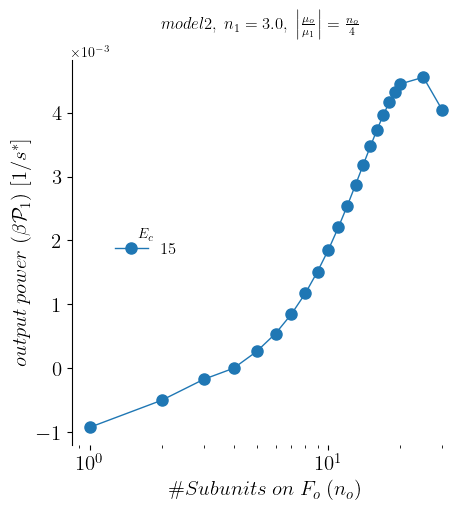

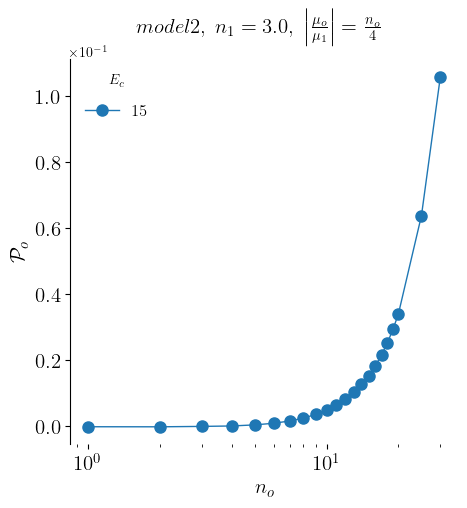

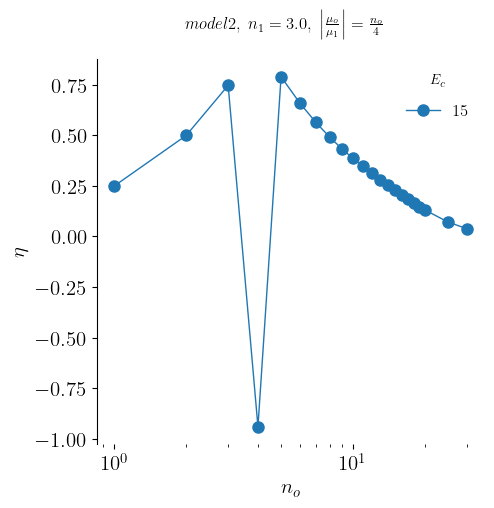

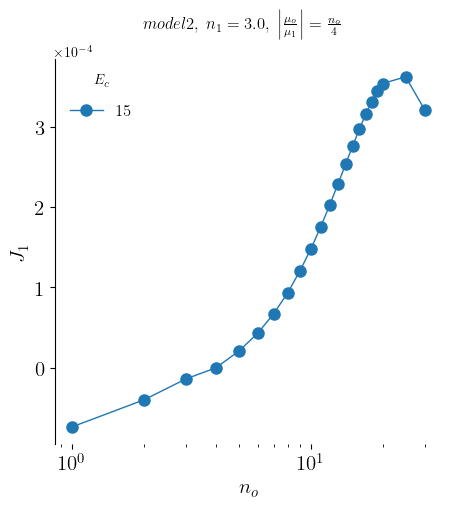

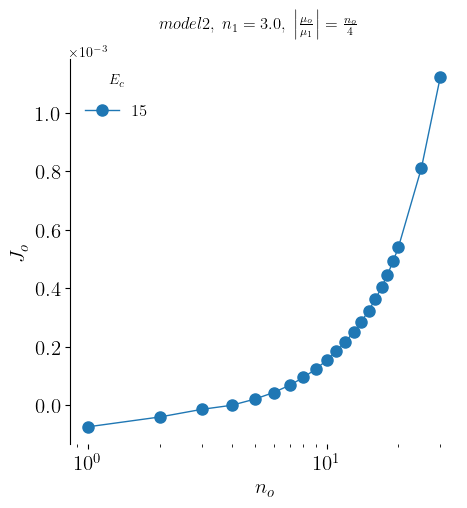

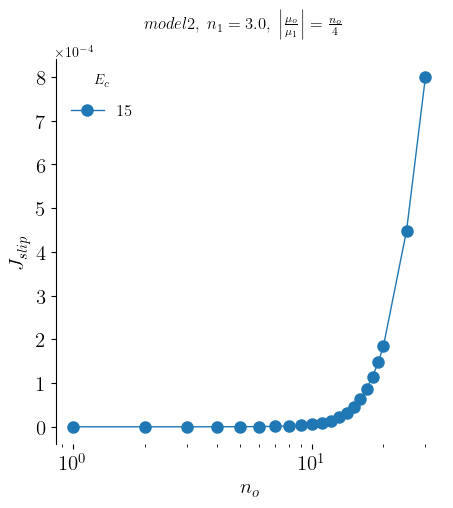

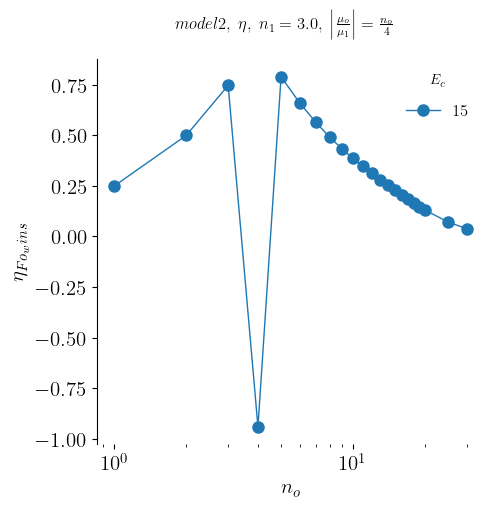

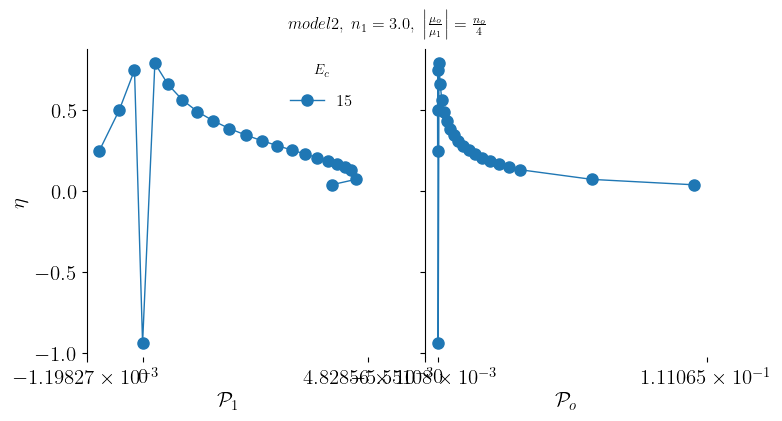

In [88]:
#A plot of P vs n0 for different Ec

Ecouple_array = [150.0]
model_array = ["model1", "model2","model3","model4"]
#model_array = ["model2"]

# target_dir ="/Users/sarealles/Desktop/model2/new_data_540_CM/f0_8/pfe/"
# target_dir="/Users/sarealles/Desktop/model2/data_540_probably_previously_downloaded_somewhere/f0_4/pfe/"

# target_dir = "/Users/sarealles/Desktop/model1/Data_N_360/cluster/pfe/"
#target_dir = "/Users/sarealles/Desktop/model1/Data_N_100/pfe/"
target_dir = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_1/f0_4/pfe/"
target_dir = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_2/f0_4/pfe/"
# target_dir="/Users/sarealles/Desktop/model2/data_540_probably_previously_downloaded_somewhere/f0_4/pfe/"
target_dir = "/Users/sarealles/Desktop/Data_processed/pfe_old/"
target_dir = "/Users/sarealles/Desktop/Data/"
target_dir = "/Users/sarealles/Desktop/model3/pfe/"
# target_dir ="/Users/sarealles/Desktop/model1/new_data_540_CM/f0_8/pfe/"
target_dir ="/Users/sarealles/Desktop/model2/Barrier_analysis/E0_2/pfe/"
target_dir = "/Users/sarealles/Desktop/model2/figure_paper/pfe/"
target_dir = "/Users/sarealles/Desktop/FIG/"
#individual plots for each model


Ec_array = [0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,32.0,40.0,50.0,64.0,70.0,80.0,90.0,128.0] 
# Ec_array = [8.0,9.0,10.0,11.0,12.0]

# Ec_array = np.array([9.0,10.0,11.0, 12.0])

# Ec_array = [7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0]

# Ec_array = [5., 6., 7., 8., 9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19.]

Ec_array = [11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,32.0,40.0,50.0,64.0,70.0,80.0,90.0,128.0] 

# Ec_array = [7.5,8.0,8.5,9.0,9.5, 10.0, 10.5, 11.0, 11.5, 12.0,12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0]
n1_array = [3.0]
n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0] 
# n0_array = [3.0,6.0,12.0]
# n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0]
Ec_array = [15]
for model in ["model2"]:
    plot_P_n0_individual(target_dir, model,n0_array,n1_array,Ec_array,f0=4.0,dt=0.001,N=540,E0=2.0,E1=2.0,vs_n0=True)
    plt.show()  
# /Users/sarealles/Desktop/model2/Barrier_analysis/E0_2/pfe/8_3

E0=0.0, f0=4.0:,
 Ec array is: [8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0] 
 n0_max is [8.364295862368406, 9.936195318034878, 11.514054088222258, 13.151869763781908, 14.800517021948968, 16.46009841268661, 18.154646131815895]
E0=4.0, f0=4.0:,
 Ec array is: [8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5] 
 n0_max is [7.15570279851086, 8.071027033054715, 9.08169999858498, 10.170293327633622, 11.34456234155003, 12.582222665540892, 13.922965108591862, 15.334548936262212, 16.867136772086443, 18.49732555061393, 20.295582188749364, 22.2399984685369, 24.35069208050377, 26.654916710270218, 29.167249015428293]
E0=4.0, f0=8.0:,
 Ec array is: [8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0] 
 n0_max is [3.7184491403634317, 4.341156195142004, 4.926881277336462, 5.381427635906874, 6.082361515729543, 6.870394285458865, 7.371411280464886, 8.04487524031632, 8.804412744882777, 9.591607564748301, 10.469506294128665, 11.42299

/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_9030/1118294150.py:36: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Desktop/model2/barrier_analysis/E0_0/pfe/21_3/model2_flux_power_efficiency_E0_0.0_E1_0.0_psi0_4.0_psi1_-2.0_n0_21.0_n1_3.0_phase_0.0_outfile.dat"
  Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_9030/1118294150.py:36: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Desktop/model2/barrier_analysis/E0_0/pfe/22_3/model2_flux_power_efficiency_E0_0.0_E1_0.0_psi0_4.0_psi1_-2.0_n0_22.0_n1_3.0_phase_0.0_outfile.dat"
  Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_9030/1118294150.py:36: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Desktop/model2/barrier_analys

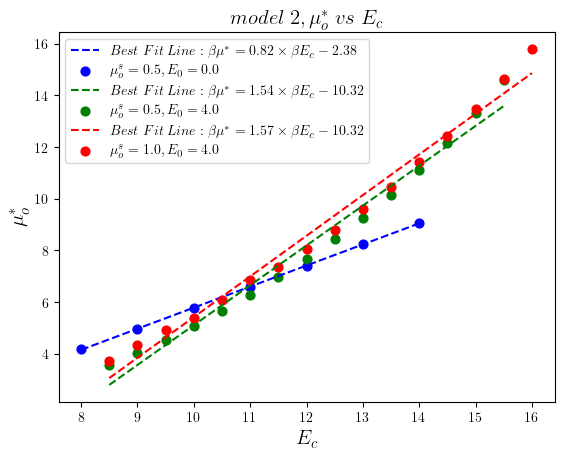

In [97]:
def around_maximum(target_dir,model,n0_array,n1_array,Ec_array,f0,E0,E1,dt,N,vs_n0=True):
    Ecouple= []
    around_maximizing_n0 = []
    P_around_maximizing_n0 = []
    if vs_n0:
        for n1 in n1_array:
            for i,Ec in enumerate(Ec_array):
                n0_exists = []
                P_at_Ec = []
                P0_at_Ec = []
                eta_at_Ec = []
                eta_at_inf = []
                eta_Fo_wins = []
                j1_at_Ec = []
                jo_at_Ec = []

                
                for n0 in n0_array:
                    # set_params(model, n0,n1,f0,f1=-2.0,E0=2.0,E1=2.0)
                    params = set_params(model, n0,n1,f0,f1,E0,E1)
                    n0n1_str = str(int(n0))+"_"+ str(int(n1))
                    target_dir_temp = target_dir + n0n1_str
                
                    [
                    E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                    m0, m1, phase,beta, gamma,__
                    ] = params

                    input_file_name = ("/" + model + "_flux_power_efficiency_"
                    + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    
                    if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
                        print(f"File does not exist: {target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)}")
                        continue

                    Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                    target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

                    # Convert Ec_list to a list if it is a single value
                    if isinstance(Ec_list, float):
                        Ec_list = [Ec_list]
                        integrate_power_Y = [integrate_power_Y]
                        integrate_power_X = [integrate_power_X]
                        integrate_flux_X = [integrate_flux_X]
                        integrate_flux_Y = [integrate_flux_Y]
                        efficiency_mod = [efficiency_mod]
                        efficiency = [efficiency]

                    # print(integrate_power_Y)
                    for j in range(len(Ec_list)):
                        if Ec_list[j] == Ec:
                            n0_exists.append(int(n0))
                            P0_at_Ec.append(2*pi*integrate_power_X[j])
                            P_at_Ec.append(-2*pi*integrate_power_Y[j])
                            eta_at_Ec.append(efficiency_mod[j])
                            j1_at_Ec.append(integrate_flux_Y[j])
                            jo_at_Ec.append(integrate_flux_X[j])
                            eta_Fo_wins.append(efficiency[j])
                if len(n0_exists)!=0 and argmax(P_at_Ec)!= argmax(n0_exists) and max(P_at_Ec)>0 :
                    # if [n0_exists[argmax(P_at_Ec)-1] , n0_exists[argmax(P_at_Ec)+1]] == [n0_exists[argmax(P_at_Ec)]-1 , n0_exists[argmax(P_at_Ec)]+1] or [n0_exists[argmax(P_at_Ec)-1] , n0_exists[argmax(P_at_Ec)+1]] == [n0_exists[argmax(P_at_Ec)]-2 , n0_exists[argmax(P_at_Ec)]+2] or [n0_exists[argmax(P_at_Ec)-1] , n0_exists[argmax(P_at_Ec)+1]] == [n0_exists[argmax(P_at_Ec)]-1 , n0_exists[argmax(P_at_Ec)]+2] or [n0_exists[argmax(P_at_Ec)-1] , n0_exists[argmax(P_at_Ec)+1]] == [n0_exists[argmax(P_at_Ec)]-2 , n0_exists[argmax(P_at_Ec)]+2] or [n0_exists[argmax(P_at_Ec)-1] , n0_exists[argmax(P_at_Ec)+1]] == [n0_exists[argmax(P_at_Ec)]-2 , n0_exists[argmax(P_at_Ec)]+1]:
                    if n0_exists[argmax(P_at_Ec)-1] in [n0_exists[argmax(P_at_Ec)]-3,n0_exists[argmax(P_at_Ec)]-2,n0_exists[argmax(P_at_Ec)]-1] and n0_exists[argmax(P_at_Ec)+1] in [n0_exists[argmax(P_at_Ec)]+1, n0_exists[argmax(P_at_Ec)]+2, n0_exists[argmax(P_at_Ec)]+3] :
    
                        # print(f"Ec is :{Ec}")
                        Ecouple.append(Ec)
                        around_maximizing_n0.append([n0_exists[argmax(P_at_Ec)-1],n0_exists[argmax(P_at_Ec)], n0_exists[argmax(P_at_Ec)]+1])
                        P_around_maximizing_n0.append([P_at_Ec[argmax(P_at_Ec)-1],P_at_Ec[argmax(P_at_Ec)], P_at_Ec[argmax(P_at_Ec)+1]])
        return Ecouple,around_maximizing_n0,P_around_maximizing_n0

def der_func(x,y):
    der = (y[2]-y[0])/(x[2]-x[0])
    derder = (y[2]-2*y[1]+y[0])/(x[2]-x[1])
    
    return der,derder


# target_dir = "/Users/sarealles/Desktop/Data_processed/pfe_old/"

# target_dir="/Users/sarealles/Desktop/model2/data_540_probably_previously_downloaded_somewhere/f0_4/pfe/"

# target_dir = "/Users/sarealles/Desktop/model1/Data_N_360/cluster/pfe/"
# target_dir = "/Users/sarealles/Desktop/model1/Data_N_100/pfe/"
# target_dir ="/Users/sarealles/Desktop/model2/new_data_540_CM/f0_4/pfe/"
target_dir ="/Users/sarealles/Desktop/model2/new_data_540_CM/E0_3/f0_8/pfe/"

    
#individual plots for each model
Ec_array = [0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,32.0,40.0,50.0,64.0,70.0,80.0,90.0,128.0] 
# Ec_array = [8.0,9.0,10.0,11.0,12.0]

# Ec_array = np.array([9.0,10.0,11.0, 12.0])

# Ec_array = [7.0,7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0,11.5,12.0,12.5,13.0,13.5,14.0,14.5,15.0,15.5,16.0]
# Ec_array = [5., 6., 7., 8., 9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27., 28., 29., 30., 31., 32., 40., 50., 60., 64., 70., 80., 90., 100., 120., 128., 130., 150.]
Ec_array = [5., 6., 7., 8., 9., 10., 11., 12., 13., 14.,15.0,16.0,17.0,18.0, 19.0]
Ec_array= [7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5]
# J1 maximizing n0 is: [5, 6, 7, 8, 9, 10, 11, 11, 13, 15, 16, 18, 19, 21, 22, 24, 26, 28, 30
# Ec is : [5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0]
# j1 maximizing n0 is: [4, 5, 7, 8, 10, 12, 13, 15, 16, 18, 20, 22, 23, 25, 27, 29]

n1_array = [3.0]
n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0] 
Ec_array_raw= [7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0]
# n0_array = [2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0] 
from cycler import cycler

import matplotlib.pyplot as plt
from cycler import cycler

fig, ax = plt.subplots()
ax.set_xlabel(r"$E_c$", fontsize=15)
ax.set_ylabel(r"$\mu_o^*$", fontsize=15)
ax.set_title(r"$model \ 2, \mu_o^* \ vs \ E_c$", fontsize=15)





f0 = 4.0; E0 = 2.0; E1 = 2.0
colors_array = ["blue","green","red","purple","orange","brown","pink","gray","olive","cyan"]
color_index = 0
for f0 in [4.0,8.0]:
    for E0 in [0.0,4.0]:
        # if f0==4.0 and E0 != 1.0:
        #     continue
        if f0 == 8.0 and E0 == 1.0:
            continue
        if f0 == 8.0 and E0 == 0.0:
            continue
        # if f0 == 4.0 and E0 == 2.0:
        #     #data exists
        #     continue
        E1  = E0
        color = colors_array[color_index]
        color_index+=1
        for model in ["model2"]:
            
            target_dir= f"/Users/sarealles/Desktop/{model}/barrier_analysis/E0_{int(E0)}/pfe/"
            Ec_array,neigh_n0,neigh_P1 = around_maximum(target_dir, model,n0_array,n1_array,Ec_array_raw,f0,E0,E1,dt=0.001,N=540,vs_n0=True)
            # print(Ec_array)
            # print(neigh_n0) 
            # print(neigh_P1) 
            n0_max = []
            for i,Ec in enumerate(Ec_array):
                n0_assumed_max = neigh_n0[i][1]
                der,derder = der_func(neigh_n0[i],neigh_P1[i])
                n0_max.append(n0_assumed_max - (der/derder))
                # n0_max = array(n0_max)
            print(f"E0={E0}, f0={f0}:,\n Ec array is: {Ec_array} \n n0_max is {n0_max}")
            slope, intercept = np.polyfit(Ec_array, (f0 / 8) * np.array(n0_max), 1)
            fit_line = slope * np.array(Ec_array) + intercept
            ax.plot(Ec_array, fit_line, linestyle="--", color= color , label=fr"$Best \ Fit \ Line: \beta\mu^* = {round(slope,2)}\times \beta E_c{round(intercept, 2)}$")
            ax.scatter(Ec_array,(f0/8)*array(n0_max), color = color, label = fr"$\mu_o^s = {f0/8}, E_0 = {E0}$",marker ="o", s=40)
ax.legend()


/Users/sarealles/Desktop/FIG/
[8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5]
assumed max: 8
assumed max: 9
assumed max: 10
assumed max: 11
assumed max: 12
assumed max: 13
assumed max: 15
assumed max: 16
assumed max: 18
assumed max: 19
assumed max: 21
assumed max: 22
assumed max: 24
assumed max: 26
assumed max: 28
real_max =  [3.817227560580137, 4.299662401981795, 4.82597864241362, 5.394482472047321, 5.996358829451777, 6.629314413964669, 7.299630389078084, 8.02160155684004, 8.766266605400508, 9.569373804275473, 10.396646887648421, 11.245188763805277, 12.126196826620108, 13.011660221211635, 13.895219511082818]
/Users/sarealles/Desktop/FIG/
[8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0]
assumed max: 7
assumed max: 8
assumed max: 9
assumed max: 10
assumed max: 12
assumed max: 13
assumed max: 14
assumed max: 15
assumed max: 16
assumed max: 17
assumed max: 19
assumed max: 20
assumed max: 20
real_max =  [3.737508855315303, 4

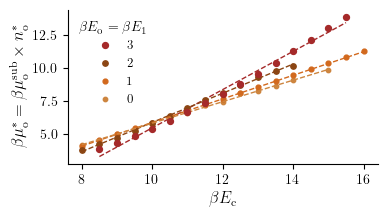

In [98]:
fig, ax = plt.subplots(figsize=(4,2))
ax.set_xlabel(r"$\beta E_{\rm c}$", fontsize=12)
ax.set_ylabel(r"$\beta \mu_{\rm o}^* = \beta \mu_{\rm o}^{\rm sub} \times n_{\rm o}^*$", fontsize=12)
# ax.set_title(r"$model \ 2 \ (averaged), \mu_o^* \ vs \ E_c$", fontsize=22)


ax.tick_params(axis='both', which='major', labelsize=10)
#data for f0=8,E0=1 does not exist
colors_array = ["sandybrown","peru","chocolate","saddlebrown","brown"][::-1]  # Reverse the order of colors
# colors_array = ["purple"]
intercept_all = []
slope_all = []
x = np.linspace(8,16,1000)
y = []
color_index = 0
size_list = [10,12,15,18]  # Different sizes for each E0
for E0 in [3.0,2.0,1.0,0.0]:

    E1  = E0
    color = colors_array[color_index]
    color_index+=1
    for model in ["model2"]:
        f0 = 4.0
        target_dir= f"/Users/sarealles/Desktop/{model}/Barrier_analysis/E0_{int(E0)}/pfe/"
        target_dir= f"/Users/sarealles/Desktop/model2/figure_paper/pfe/"
        target_dir= f"/Users/sarealles/Desktop/FIG/"

        print(target_dir)
        Ec_array_4,neigh_n0_4,neigh_P1_4 = around_maximum(target_dir, model,n0_array,n1_array,Ec_array_raw,f0,E0,E1,dt=0.001,N=540,vs_n0=True)
        print(Ec_array_4)
        mu0_max_4 = []
        for i,Ec in enumerate(Ec_array_4):
            n0_assumed_max = neigh_n0_4[i][1]
            print("assumed max:", n0_assumed_max)
            der,derder = der_func(neigh_n0_4[i],neigh_P1_4[i])
            mu0_max_4.append(0.5*(n0_assumed_max - (der/derder)))
        print("real_max = " , mu0_max_4)
        # if E0 != 1.0 and E0  != 0.0 :
        if False:
            f0 = 8.0    
            Ec_array_8,neigh_n0_8,neigh_P1_8 = around_maximum(target_dir, model,n0_array,n1_array,Ec_array_raw,f0,E0,E1,dt=0.001,N=540,vs_n0=True)
            mu0_max_8 = []
            for i,Ec in enumerate(Ec_array_8):
                n0_assumed_max = neigh_n0_8[i][1]
                der,derder = der_func(neigh_n0_8[i],neigh_P1_8[i])
                mu0_max_8.append(n0_assumed_max - (der/derder))
        else:
            mu0_max_8 = []
            Ec_array_8 = []
            
        

 
        Ec_array_4.extend(Ec_array_8)
        mu0_max_4.extend(mu0_max_8)

        sorted_indices = np.argsort(Ec_array_4)
        Ec_array_sorted = array(Ec_array_4)[sorted_indices]
        mu0_array_sorted = array(mu0_max_4)[sorted_indices]
        
        #, linestyle="--"
        slope, intercept = np.polyfit(Ec_array_sorted, mu0_array_sorted, 1)
        fit_line = slope * np.array(Ec_array_sorted) + intercept
        
        ax.plot(Ec_array_sorted, fit_line, color= color , lw=1,linestyle="--",label="")
        ax.scatter(Ec_array_sorted,mu0_array_sorted, color = color, label = fr"${int(E0)}$",marker ="o", s=size_list[int(E0)], zorder=E0)
        y.append(slope*array(x)+intercept)


        '''poster chnages'''
        # ax.plot(Ec_array_sorted, fit_line, color= color , linestyle="--", lw=1.0)
        
        
        

        

critical_points = []
# argmax_list = [argmax([y[0][j], y[1][j], y[2][j], y[3][j], y[4][j]]) for j in range(len(y[0]))]

# for i in range(len(argmax_list) - 1):
#     if argmax_list[i] != argmax_list[i + 1]:
#         critical_points.append(x[i])
#         ax.vlines(x[i],2.5,15,linestyle="--",color="black")

print(critical_points)
# ax.set_xscale("log")
  
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.legend(framealpha=1, facecolor='white')  # Remove transparency  
# ax.legend(framealpha=1, frameon =False,facecolor='white', prop={'size': 15})  



ax.legend(title=r"$\beta E_{\rm o} = \beta E_1$", title_fontsize=10, frameon=False, facecolor='white', prop={'size': 9})
# fig.savefig("/Users/sarealles/Desktop/research/BSC2025/mu0_star_vs_Ec_grad.pdf",bbox_inches='tight')
fig.savefig("/Users/sarealles/Desktop/research/Paper/mu0_star_vs_Ec_grad_new.pdf",bbox_inches='tight')



# the previous process for new data

/Users/sarealles/Desktop/model2/figure_paper/pfe/
[8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0]
mu0 is 4.0, E0 is 2.0 and max mu0 is [3.482129841456017, 4.357841898766105, 3.600443809471099, 6.485220834355828, 6.4908842722887075, 6.536006458538807, 6.403572912688012, 7.098205003078011, 8.566638636860436, 8.582232045462591, 9.031476889140942, 9.112151617172646, 10.884888713950824, 12.432898331969154, 12.445082671794262, 12.455987092375505, 12.291518681806403]
/Users/sarealles/Desktop/model2/figure_paper/pfe/
File does not exist: /Users/sarealles/Desktop/model2/figure_paper/pfe/1_3/model2_flux_power_efficiency_E0_2.0_E1_2.0_psi0_8.0_psi1_-2.0_n0_1.0_n1_3.0_phase_0.0_outfile.dat
File does not exist: /Users/sarealles/Desktop/model2/figure_paper/pfe/2_3/model2_flux_power_efficiency_E0_2.0_E1_2.0_psi0_8.0_psi1_-2.0_n0_2.0_n1_3.0_phase_0.0_outfile.dat
File does not exist: /Users/sarealles/Desktop/model2/figure_paper/pfe/3_3/model2_flux_powe

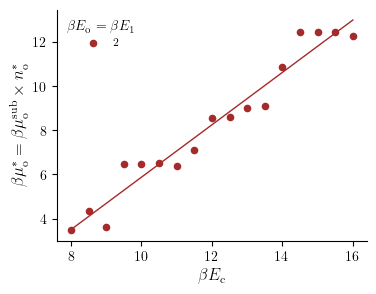

In [59]:
fig, ax = plt.subplots(figsize=(4,3))
ax.set_xlabel(r"$\beta E_{\rm c}$", fontsize=12)
ax.set_ylabel(r"$\beta \mu_{\rm o}^* = \beta \mu_{\rm o}^{\rm sub} \times n_{\rm o}^*$", fontsize=12)
# ax.set_title(r"$model \ 2 \ (averaged), \mu_o^* \ vs \ E_c$", fontsize=22)


ax.tick_params(axis='both', which='major', labelsize=10)
#data for f0=8,E0=1 does not exist
colors_array = ["sandybrown","peru","chocolate","saddlebrown","brown"][::-1]  # Reverse the order of colors
# colors_array = ["purple"]
intercept_all = []
slope_all = []
x = np.linspace(8,16,1000)
y = []
ls = ["solid","--"]
size_list = [20,40]
color_index = 0
model = "model2"
for E0 in [2.0]:
    E1  = E0
    color = colors_array[color_index]
    color_index+=1
    
    for h,f0 in enumerate([4.0,8.0]):
        mu0_max = []
        target_dir= f"/Users/sarealles/Desktop/{model}/figure_paper/pfe/"

        print(target_dir)
        Ec_array,neigh_n0,neigh_P1 = around_maximum(target_dir, model,n0_array,n1_array,Ec_array_raw,f0,E0,E1,dt=0.001,N=540,vs_n0=True)
        print(Ec_array)
        
        for i,Ec in enumerate(Ec_array):
            n0_assumed_max = neigh_n0[i][1]
            der,derder = der_func(neigh_n0[i],neigh_P1[i])
            mu0_max.append((f0/8)*(n0_assumed_max - (der/derder)))
        print(f"mu0 is {f0}, E0 is {E0} and max mu0 is {mu0_max}")

        
        sorted_indices = np.argsort(Ec_array)
        Ec_array_sorted = array(Ec_array)[sorted_indices]
        mu0_array_sorted = array(mu0_max)[sorted_indices]
        #, linestyle="--"
        if len(mu0_array_sorted) == 0:
            print(f"No data for E0={E0}, f0={f0}. Skipping...")
            continue
        else:
            slope, intercept = np.polyfit(Ec_array_sorted, mu0_array_sorted, 1)
            fit_line = slope * np.array(Ec_array_sorted) + intercept
            
            ax.plot(Ec_array_sorted, fit_line, color= color , lw=1,linestyle=ls[h],label="")
            ax.scatter(Ec_array_sorted,mu0_array_sorted, color = color, label = fr"${int(E0)}$",marker ="o", s=size_list[h], zorder=E0)
            y.append(slope*array(x)+intercept)


        '''poster chnages'''
        # ax.plot(Ec_array_sorted, fit_line, color= color , linestyle="--", lw=1.0)
        
        
        

        

critical_points = []
# argmax_list = [argmax([y[0][j], y[1][j], y[2][j], y[3][j], y[4][j]]) for j in range(len(y[0]))]

# for i in range(len(argmax_list) - 1):
#     if argmax_list[i] != argmax_list[i + 1]:
#         critical_points.append(x[i])
#         ax.vlines(x[i],2.5,15,linestyle="--",color="black")

print(critical_points)
# ax.set_xscale("log")
  
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.legend(framealpha=1, facecolor='white')  # Remove transparency  
# ax.legend(framealpha=1, frameon =False,facecolor='white', prop={'size': 15})  



ax.legend(title=r"$\beta E_{\rm o} = \beta E_1$", title_fontsize=10, frameon=False, facecolor='white', prop={'size': 8})
# fig.savefig("/Users/sarealles/Desktop/research/BSC2025/mu0_star_vs_Ec_grad.pdf",bbox_inches='tight')
# fig.savefig("/Users/sarealles/Desktop/research/Paper/mu0_star_vs_Ec_single.pdf",bbox_inches='tight')



# P1 vs n0 for different E0 at fixed Ec

In [60]:
def plot_P_n0_E0_lines(target_dir,model,n0_array,n1_array,E0_array,Ec,f0,dt,N,E0,E1,vs_n0=True):
    timescale = 1.5 * 10**4 
    #individually plotting for each model P vs no for various Ec values in one single plot

    #fig for P vs n0
    fig, ax = plt.subplots(1, 1, figsize=(5,5))
    #fig6 for P0 vs n0
    fig6, ax6 = plt.subplots(1, 1, figsize=(5,5))
    #fig1 for eta vs n0
    fig1, ax1 = plt.subplots(1, 1, figsize=(5,5))
    #fig2 for j1 vs n0
    fig2, ax2 = plt.subplots(1, 1, figsize=(5,5))
    #fig2 for jo vs n0
    fig5, ax5 = plt.subplots(1, 1, figsize=(5,5))
    #fig3 for jslip vs n0
    fig3, ax3 = plt.subplots(1, 1, figsize=(5,5))
    # #fig4 for eta if assume fo always wins
    fig4, ax4 = plt.subplots(1, 1, figsize=(5,5))
    #fig7 P1 vs. eta
    fig7, ax7 = plt.subplots(1, 2, figsize=(8,4), sharey="row")
    
    # ax.axhline(0.0,color="black", lw=1.0)
    # ax3.axhline(0.0,color="black", lw=1.0)
    # ax6.axhline(0.0,color="black", lw=1.0)
    # ax4.axhline(0.0,color="black", lw=1.0)
    # ax2.axhline(0.0,color="black", lw=1.0)
    # ax5.axhline(0.0,color="black", lw=1.0)
    # ax1.axhline(1.0,color="black", lw=1.0)
    
    index = int(model[-1])-1
    Ecouple= []
    maximizing_n0 = []
    if vs_n0:
        for n1 in n1_array:
            for i,E0 in enumerate(E0_array):
                n0_exists = []
                P_at_E0 = []
                P0_at_E0 = []
                eta_at_E0 = []
                eta_at_inf = []
                eta_Fo_wins = []
                j1_at_E0 = []
                jo_at_E0 = []
                jslip_at_E0 = []
                
                for n0 in n0_array:
                    params = set_params(model, n0,n1,f0,f1,E0,E1)
                    n0n1_str = str(int(n0))+"_"+ str(int(n1))
                    target_dir_temp = target_dir + n0n1_str
                
                    [
                    E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                    m0, m1, phase,beta, gamma,__
                    ] = params
                    
                
                    # input_file_name = ("/" + model +"_dt_{7}_N_{8}"+ "_flux_power_efficiency_"
                    # + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    #change the input name
                    input_file_name = ("/" + model + "_flux_power_efficiency_"
                    + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    
                    if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
                        continue

                    Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                    target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

                    # Convert Ec_list to a list if it is a single value
                    if isinstance(Ec_list, float):
                        Ec_list = [Ec_list]
                        integrate_power_Y = [integrate_power_Y]
                        integrate_power_X = [integrate_power_X]
                        integrate_flux_X = [integrate_flux_X]
                        integrate_flux_Y = [integrate_flux_Y]
                        efficiency_mod = [efficiency_mod]
                        efficiency = [efficiency]

                    # print(integrate_power_Y)
                    for j in range(len(Ec_list)):
                        if Ec_list[j] == Ec:
                            n0_exists.append(int(n0))
                            P0_at_Ec.append(2*pi*integrate_power_X[j])
                            P_at_Ec.append(-2*pi*integrate_power_Y[j])
                            eta_at_Ec.append(efficiency_mod[j])
                            j1_at_Ec.append(integrate_flux_Y[j])
                            jo_at_Ec.append(integrate_flux_X[j])
                            eta_Fo_wins.append(efficiency[j])
                            if model =="model3" or model=="model4":
                                jslip_at_Ec.append(n0*integrate_flux_X[j]-n1*integrate_flux_Y[j])
                            else:
                                jslip_at_Ec.append(integrate_flux_X[j]-integrate_flux_Y[j])
                                
                            
                    eta_at_inf.append(infinite_eff(psi_0,psi_1,n0,n1,model))
                print("J0: ",jo_at_Ec)
                print("J1: ",j1_at_Ec)
                print("eff is ",eta_at_Ec)
                print("n0: ",n0_exists)
                if len(n0_exists)!=0:
                    Ecouple.append(Ec)
                    maximizing_n0.append(n0_exists[argmax(j1_at_Ec)])
                # print(fr"at {Ec}, n0 that maximizes J1 is: {n0_exists[argmax(j1_at_Ec)]}")
                    
                if model =="model2" or model=="model4":
                    x = str(psi_0/8)
                    psi_0 = "\\frac{n_o}{4}"
                    # psi_0 = str(psi_0)
                    f_o = "\\left| \\frac{\\mu_o}{\\mu_1} \\right|"
                else:
                    # f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                    f_o = "\\Delta \\mu_o"
                    
                fig.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax.plot(n0_exists,P_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax.tick_params(labelsize=15, axis='both')
                ax.set_xlabel(r"$ \#Subunits \ on \ F_o \ (n_o)$", fontsize=15)
                ax.set_xticks(n0_exists)
                ax.set_ylabel(r"$output \ power\ (\beta\mathcal{P}_{1})\ [1/s^*]$", fontsize=15)
                #ax.legend(loc='upper right', prop={'size':12})
                # ax.plot([6,9,12,15,18,21,24,27,30],[1.0, 0.989, 0.961, 0.916, 0.854, 0.791, 0.81, 0.83, 0.836])
                #############################♯
                # deg=4
                # fit_coeffs = np.polyfit(n0_exists, P_at_Ec, deg)
                # fit_curve = np.polyval(fit_coeffs, n0_exists)
                # equation = " + ".join([f"${coef:.6f}*x^{deg}$" for coef, deg in zip(fit_coeffs, range(len(fit_coeffs)-1, -1, -1))])
                # print(f"Fitted Polynomial Equation Ec = {Ec}: y = {equation}")
                # ax.plot(n0_exists, fit_curve)
                # print(f"Fitted Polynomial Equation: y = {equation}")
                ############################# 
                fig1.suptitle(fr"${model} ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax1.plot(n0_exists,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                for i,e in enumerate(eta_at_Ec):
                    if e > 0.5:
                        print(fr"eta is {e} at Ec = {Ec}, n0 = {n0_exists[i]}")
        
                ax1.tick_params(labelsize=15, axis='both')
                ax1.set_xlabel(r"$n_o$", fontsize=15)
                ax1.set_ylabel(r"$\eta$", fontsize=15)
                #ax1.legend(loc='upper right', prop={'size':12})
                
                fig7.suptitle(fr"${model} ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax7[0].plot(P_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax7[1].plot(P0_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                # ax7[1].set_title(r"$\mathcal{P}_{o}$")
                # ax7[0].set_title(r"$\mathcal{P}_{1}$")
                ax7[0].tick_params(labelsize=15, axis='both')
                ax7[1].tick_params(labelsize=15, axis='both')
                ax7[0].set_xlabel(r"$\mathcal{P}_{1}$", fontsize=15)
                ax7[1].set_xlabel(r"$\mathcal{P}_{o}$", fontsize=15)
                ax7[0].set_ylabel(r"$\eta$", fontsize=15)
                
                fig2.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax2.plot(n0_exists,j1_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax2.tick_params(labelsize=15, axis='both')
                ax2.set_xlabel(r"$n_o$", fontsize=15)
                ax2.set_xticks(n0_exists)
                ax2.set_ylabel(r"$J_{1}$", fontsize=15)
                
                fig5.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax5.plot(n0_exists,jo_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax5.tick_params(labelsize=15, axis='both')
                ax5.set_xlabel(r"$n_o$", fontsize=15)
                ax5.set_xticks(n0_exists)
                ax5.set_ylabel(r"$J_{o}$", fontsize=15)
                
                fig3.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax3.plot(n0_exists,jslip_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax3.tick_params(labelsize=15, axis='both')
                ax3.set_xlabel(r"$n_o$", fontsize=15)
                ax3.set_xticks(n0_exists)
                ax3.set_ylabel(r"$J_{slip}$", fontsize=15)

                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                fig4.suptitle(fr"${model},\ \eta ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax4.plot(n0_exists,eta_Fo_wins, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax4.tick_params(labelsize=15, axis='both')
                ax4.set_xlabel(r"$n_o$", fontsize=15)
                ax4.set_xticks(n0_exists)
                ax4.set_ylabel(r"$\eta_{Fo_wins}$", fontsize=15)


                fig6.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=15)
                ax6.plot(n0_exists,P0_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax6.tick_params(labelsize=15, axis='both')
                ax6.set_xlabel(r"$n_o$", fontsize=15)
                ax6.set_xticks(n0_exists)
                ax6.set_ylabel(r"$\mathcal{P}_{o}$", fontsize=15)
                
                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax2.spines['right'].set_visible(False)
                ax2.spines['bottom'].set_visible(False)
                ax2.spines['top'].set_visible(False)
                
                ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax5.spines['right'].set_visible(False)
                ax5.spines['bottom'].set_visible(False)
                ax5.spines['top'].set_visible(False)
                
                ax7[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[0].spines['right'].set_visible(False)
                ax7[0].spines['bottom'].set_visible(False)
                ax7[0].spines['top'].set_visible(False)
                ax7[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[1].spines['right'].set_visible(False)
                ax7[1].spines['bottom'].set_visible(False)
                ax7[1].spines['top'].set_visible(False)
                
                ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax6.spines['right'].set_visible(False)
                ax6.spines['bottom'].set_visible(False)
                ax6.spines['top'].set_visible(False)
                
                ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax4.spines['right'].set_visible(False)
                ax4.spines['bottom'].set_visible(False)
                ax4.spines['top'].set_visible(False)
                
                ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax3.spines['right'].set_visible(False)
                ax3.spines['bottom'].set_visible(False)
                ax3.spines['top'].set_visible(False)
                
                ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax1.spines['right'].set_visible(False)
                ax1.spines['bottom'].set_visible(False)
                ax1.spines['top'].set_visible(False)
                
                ax.set_xscale("log")
                ax1.set_xscale("log")
                ax2.set_xscale("log")
                ax3.set_xscale("log")
                ax4.set_xscale("log")
                ax5.set_xscale("log")
                ax6.set_xscale("log")
                ax7[0].set_xscale("symlog")
                ax7[1].set_xscale("symlog")
                
            
                #ax.set_yscale("log")
            # ax1.plot(n0_array, eta_at_inf, label=fr"$E_{{\infty}}$", color="black", markersize=15)
        
        # ax1.plot([3,6,9,12,15,18,21], [0.36, 0.18, 0.12, 0.09, 0.07, 0.06, 0.05], label="8")
        # ax1.plot([3,6,9,12,15,18,21],[0.66, 0.59, 0.63, 0.65, 0.65, 0.65, 0.65], label = "12")
        # ax1.plot([3,6,9,12,15,18,21],[0.44, 0.2, 0.14, 0.11, 0.09, 0.07, 0.06],label = "12*limit")
        ax.legend(prop={'size': 12}, title='$E_c$', frameon=False, ncol=1, labelspacing=0.05,
            bbox_to_anchor=(0.31, 0.6), loc='best')
        # ax.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax1.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax2.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax3.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax4.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax6.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax5.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax7[0].legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        # fig.savefig(fr"/Users/sarealles/Desktop/research/nov24/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{f0}.pdf")
        # fig.savefig(fr"/Users/sarealles/Desktop/research/nov24/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{f0}.png",dpi=500)
        # fig1.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_eta_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig2.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_J1_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")

        print("Ec is :", Ecouple)
        print("j1 maximizing n0 is:", maximizing_n0)
        plt.show()
        
    
    else:
        for n0 in n0_array:
            for i,Ec in enumerate(Ec_array):
                n1_exists = []
                P_at_Ec = []
                P0_at_Ec = []
                eta_at_Ec = []
                eta_at_inf = []
                eta_Fo_wins = []
                j1_at_Ec = []
                jo_at_Ec = []
                jslip_at_Ec = []
                
                for n1 in n1_array:
                    params = set_params_Fo_8(model, n0,n1)
                    n0n1_str = str(int(n0))+"_"+ str(int(n1))
                    target_dir_temp = target_dir + n0n1_str
                
                    [
                    E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                    m0, m1, phase,beta, gamma,__
                    ] = params
                    
                
                    # input_file_name = ("/" + model +"_dt_{7}_N_{8}"+ "_flux_power_efficiency_"
                    # + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    #change the input name
                    input_file_name = ("/" + model + "_flux_power_efficiency_"
                    + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    
                    if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
                        continue

                    Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                    target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

                    # Convert Ec_list to a list if it is a single value
                    if isinstance(Ec_list, float):
                        Ec_list = [Ec_list]
                        integrate_power_Y = [integrate_power_Y]
                        integrate_power_X = [integrate_power_X]
                        integrate_flux_X = [integrate_flux_X]
                        integrate_flux_Y = [integrate_flux_Y]
                        efficiency_mod = [efficiency_mod]
                        efficiency = [efficiency]

                    # print(integrate_power_Y)
                    for j in range(len(Ec_list)):
                        if Ec_list[j] == Ec:
                            n1_exists.append(int(n1))
                            P0_at_Ec.append(2*pi*integrate_power_X[j])
                            P_at_Ec.append(-2*pi*integrate_power_Y[j])
                            eta_at_Ec.append(efficiency_mod[j])
                            j1_at_Ec.append(integrate_flux_Y[j])
                            jo_at_Ec.append(integrate_flux_X[j])
                            eta_Fo_wins.append(efficiency[j])
                            if model =="model3" or model=="model4":
                                jslip_at_Ec.append(n0*integrate_flux_X[j]-n1*integrate_flux_Y[j])
                            else:
                                jslip_at_Ec.append(integrate_flux_X[j]-integrate_flux_Y[j])
                                
                            
                    eta_at_inf.append(infinite_eff(psi_0,psi_1,n0,n1,model))
                print("J0: ",jo_at_Ec)
                print("J1: ",j1_at_Ec)
                print("eff is ",eta_at_Ec)
                print("n1: ",n1_exists)
                    
                if model =="model2" or model=="model4":
                    x = str(psi_0/8)
                    psi_0 = "\\frac{n_o}{4}"
                    f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                else:
                    psi_0 = 2
                    f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                    
                fig.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax.plot(n1_exists,P_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax.tick_params(labelsize=15, axis='both')
                ax.set_xlabel(r"$n_1$", fontsize=15)
                ax.set_xticks(n1_exists)
                ax.set_ylabel(r"$\mathcal{P}_{1}$", fontsize=15)
                #ax.legend(loc='upper right', prop={'size':12})

                fig1.suptitle(fr"${model} ,\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax1.plot(n1_exists,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                for i,e in enumerate(eta_at_Ec):
                    if e > 0.5:
                        print(fr"eta is {e} at Ec = {Ec}, n1 = {n1_exists[i]}")
                    
                        
                ax1.tick_params(labelsize=15, axis='both')
                ax1.set_xlabel(r"$n_1$", fontsize=15)
                ax1.set_ylabel(r"$\eta$", fontsize=15)
                #ax1.legend(loc='upper right', prop={'size':12})
                
                fig7.suptitle(fr"${model} ,\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax7[0].plot(P_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax7[1].plot(P0_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                # ax7[1].set_title(r"$\mathcal{P}_{o}$")
                # ax7[0].set_title(r"$\mathcal{P}_{1}$")
                ax7[0].tick_params(labelsize=15, axis='both')
                ax7[1].tick_params(labelsize=15, axis='both')
                ax7[0].set_xlabel(r"$\mathcal{P}_{1}$", fontsize=15)
                ax7[1].set_xlabel(r"$\mathcal{P}_{o}$", fontsize=15)
                ax7[0].set_ylabel(r"$\eta$", fontsize=15)
                
                fig2.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax2.plot(n1_exists,j1_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax2.tick_params(labelsize=15, axis='both')
                ax2.set_xlabel(r"$n_1$", fontsize=15)
                ax2.set_xticks(n1_exists)
                ax2.set_ylabel(r"$J_{1}$", fontsize=15)
                
                fig5.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax5.plot(n1_exists,jo_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax5.tick_params(labelsize=15, axis='both')
                ax5.set_xlabel(r"$n_1$", fontsize=15)
                ax5.set_xticks(n1_exists)
                ax5.set_ylabel(r"$J_{o}$", fontsize=15)
                
                fig3.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax3.plot(n1_exists,jslip_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax3.tick_params(labelsize=15, axis='both')
                ax3.set_xlabel(r"$n_1$", fontsize=15)
                ax3.set_xticks(n1_exists)
                ax3.set_ylabel(r"$J_{slip}$", fontsize=15)

                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                fig4.suptitle(fr"${model},\ \eta ,\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax4.plot(n1_exists,eta_Fo_wins, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax4.tick_params(labelsize=15, axis='both')
                ax4.set_xlabel(r"$n_1$", fontsize=15)
                ax4.set_xticks(n1_exists)
                ax4.set_ylabel(r"$\eta_{Fo_wins}$", fontsize=15)


                fig6.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=15)
                ax6.plot(n1_exists,P0_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax6.tick_params(labelsize=15, axis='both')
                ax6.set_xlabel(r"$n_1$", fontsize=15)
                ax6.set_xticks(n1_exists)
                ax6.set_ylabel(r"$\mathcal{P}_{o}$", fontsize=15)
                
                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax2.spines['right'].set_visible(False)
                ax2.spines['bottom'].set_visible(False)
                ax2.spines['top'].set_visible(False)
                
                ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax5.spines['right'].set_visible(False)
                ax5.spines['bottom'].set_visible(False)
                ax5.spines['top'].set_visible(False)
                
                ax7[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[0].spines['right'].set_visible(False)
                ax7[0].spines['bottom'].set_visible(False)
                ax7[0].spines['top'].set_visible(False)
                ax7[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[1].spines['right'].set_visible(False)
                ax7[1].spines['bottom'].set_visible(False)
                ax7[1].spines['top'].set_visible(False)
                
                ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax6.spines['right'].set_visible(False)
                ax6.spines['bottom'].set_visible(False)
                ax6.spines['top'].set_visible(False)
                
                ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax4.spines['right'].set_visible(False)
                ax4.spines['bottom'].set_visible(False)
                ax4.spines['top'].set_visible(False)
                
                ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax3.spines['right'].set_visible(False)
                ax3.spines['bottom'].set_visible(False)
                ax3.spines['top'].set_visible(False)
                
                ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax1.spines['right'].set_visible(False)
                ax1.spines['bottom'].set_visible(False)
                ax1.spines['top'].set_visible(False)
                
                ax.set_xscale("log")
                ax1.set_xscale("log")
                ax2.set_xscale("log")
                ax3.set_xscale("log")
                ax4.set_xscale("log")
                ax5.set_xscale("log")
                ax6.set_xscale("log")
                ax7[0].set_xscale("symlog")
                ax7[1].set_xscale("symlog")
                
            
                #ax.set_yscale("log")
            # ax1.plot(n0_array, eta_at_inf, label=fr"$E_{{\infty}}$", color="black", markersize=15)
        
        ax.legend(prop={'size': 12}, title='$E_c$', frameon=False, ncol=1, labelspacing=1,
            bbox_to_anchor=(0.31, 0.6), loc='center')
        # ax.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax1.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax2.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax3.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax4.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax6.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax5.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax7[0].legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        # fig.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig1.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_eta_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig2.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_J1_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        plt.show()

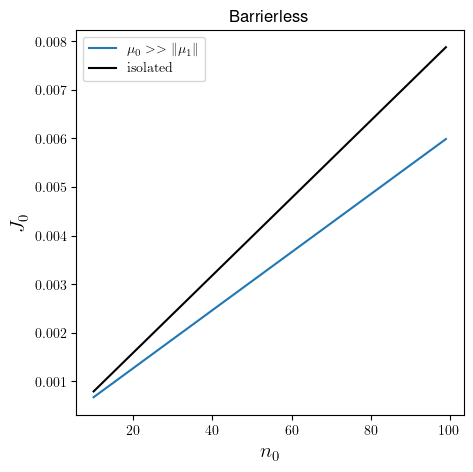

In [61]:
fig,ax = plt.subplots(1, 1, figsize=(5,5))
ax.set_title("Barrierless")
ax.set_xlabel(r"$n_0$", fontsize=15)
ax.set_ylabel(r"$J_0$", fontsize=15)

mu1 = arange(-0.475,-0.01,0.001)
n0 = arange(10,100,1)
mu0 = 0.5*n0
# mu1 = mu0-2
gamma = 1000

mu1 = -2
J_inf = (1.5*mu0 -0.5*mu1)/(4*pi*gamma)
# J_isol = mu0/(2*pi*gamma)

J_isol = 100/(2*pi*gamma)
J_isol = mu0/(2*pi*gamma)
################
ax.plot(n0,J_inf, label = r"$\mu_0 >> \| \mu_1\|$")
# ax.hlines(J_isol, xmin= min(n0),xmax=max(n0), label = r"$\mathrm{isolated}$",color="black")
ax.plot(n0, J_isol, label = r"$\mathrm{isolated}$",color="black")
# ax.set_xscale("log")
ax.legend()